# Análisis de Popularidad en Spotify y Predicción con ML

---

## Datasets

Se utilizan dos conjuntos de datos extraídos de la API de Spotify:

| Dataset | Descripción |
|---|---|
| `high_popularity_spotify_data.csv` | Canciones con **alta popularidad** en Spotify |
| `low_popularity_spotify_data.csv` | Canciones con **baja popularidad** en Spotify |

Cada dataset contiene variables de audio como: `energy`, `tempo`, `danceability`,
`loudness`, `valence`, `acousticness`, `speechiness`, entre otras.

**Fuente:** [Spotify Music Dataset — Kaggle](https://www.kaggle.com/datasets/solomonameh/spotify-music-dataset)

---

## Objetivo

Analizar y comparar ambos datasets para determinar qué canciones han tenido:

- **Mayor popularidad** — según el score de popularidad de Spotify
- **Mayor danzabilidad** — qué tan aptas son las canciones para bailar
- **Mayor audiencia** — alcance e impacto entre los oyentes de Spotify

A través de un análisis exploratorio de datos (EDA) con **Pandas**, **Matplotlib** y
**Seaborn**, se busca identificar los factores que diferencian las canciones más
escuchadas y bailadas de aquellas con menor impacto en la plataforma.

---

## Machine Learning

Adicionalmente, se aplican modelos de **Machine Learning** para:

- **Predecir** si una canción tendrá alta o baja popularidad en base a sus
  características de audio, utilizando **Random Forest** y **Regresión Logística**
- **Caso especial 1** — Analizar el impacto post-fallecimiento de un artista
  en la popularidad de sus canciones
- **Caso especial 2** — Evaluar el legado de **Avicii** en el género
  *Electronic (EDM)*, simulando la evolución de su popularidad desde
  abril de 2018 hasta 2024

---

## Librerías utilizadas

| Librería | Uso |
|---|---|
| `pandas` | Carga, limpieza y manipulación de datos |
| `matplotlib` | Visualizaciones y gráficos |
| `seaborn` | Visualizaciones estadísticas avanzadas |
| `scikit-learn` | Modelos de Machine Learning |
| `numpy` | Operaciones numéricas y simulaciones |

## 1. Importar dependencias

In [1]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 2. Cargar datasets

In [2]:
# Esto abre un botón para subir archivos desde tu computadora
uploaded = files.upload()

Saving high_popularity_spotify_data.csv to high_popularity_spotify_data.csv
Saving low_popularity_spotify_data.csv to low_popularity_spotify_data.csv


In [3]:
# Cargar los CSVs (Cada numerador de fila empieza por 1)
df_high = pd.read_csv('high_popularity_spotify_data.csv', index_col=False)
df_low = pd.read_csv('low_popularity_spotify_data.csv', index_col=False)

In [4]:
# Verificar que cargaron bien
print(df_high.shape)
print(df_low.shape)

(1686, 29)
(3145, 29)


In [5]:
df_high.index += 1
df_low.index += 1

In [6]:
df_high.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
1,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
5,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [7]:
df_low.head()

,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,track_album_id,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name
1,4.0,23,0.0393,0.636,Rock Classics,Creedence Clearwater Revival,138053.0,0.746,rock,classic,...,4A8gFwqd9jTtnsNwUu3OQx,37i9dQZF1DWXRqgorJj26U,5e6x5YRnMJIKvYpZxLqdpH,0.432,0.0,132.310,-3.785,0.0648,0.1730,The Long Road Home - The Ultimate John Fogerty...
2,4.0,53,0.0317,0.572,Rock Classics,Van Halen,241600.0,0.835,rock,classic,...,2c965LEDRNrXXCeBOAAwns,37i9dQZF1DWXRqgorJj26U,5FqYA8KfiwsQvyBI4IamnY,0.795,0.0,129.981,-6.219,0.1710,0.0702,The Collection
3,4.0,55,0.0454,0.591,Rock Classics,Stevie Nicks,329413.0,0.804,rock,classic,...,3S404OgKoVQSJ3xXrDVlp8,37i9dQZF1DWXRqgorJj26U,5LNiqEqpDc8TuqPy79kDBu,0.658,0.0,111.457,-7.299,0.3270,0.0818,Bella Donna (Deluxe Edition)
4,4.0,64,0.1010,0.443,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",185160.0,0.104,jazz,classic,...,1y5KGkUKO0NG32MhIIagCA,37i9dQZF1DXbITWG1ZJKYt,78MI7mu1LV1k4IA2HzKmHe,0.394,0.0,76.474,-17.042,0.9130,0.1910,"Love, Ella"
5,4.0,62,0.0298,0.685,Jazz Classics,Galt MacDermot,205720.0,0.472,jazz,classic,...,6f4b9wVTkKAf096k4XG6x5,37i9dQZF1DXbITWG1ZJKYt,6MN6yRVriszuyAVlyF8ndB,0.475,9.0,80.487,-9.691,0.7850,0.2240,Shapes of Rhythm/Woman Is Sweeter


## 3. Información de los datasets

In [8]:
# Información de dataset (high_popularity)
df_high.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 1 to 1686
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    1686 non-null   float64
 1   tempo                     1686 non-null   float64
 2   danceability              1686 non-null   float64
 3   playlist_genre            1686 non-null   object 
 4   loudness                  1686 non-null   float64
 5   liveness                  1686 non-null   float64
 6   valence                   1686 non-null   float64
 7   track_artist              1686 non-null   object 
 8   time_signature            1686 non-null   int64  
 9   speechiness               1686 non-null   float64
 10  track_popularity          1686 non-null   int64  
 11  track_href                1686 non-null   object 
 12  uri                       1686 non-null   object 
 13  track_album_name          1685 non-null   object 
 14  playlist

In [9]:
# Información de dataset (low_popularity)
df_low.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3145 entries, 1 to 3145
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time_signature            3144 non-null   float64
 1   track_popularity          3145 non-null   int64  
 2   speechiness               3144 non-null   float64
 3   danceability              3144 non-null   float64
 4   playlist_name             3145 non-null   object 
 5   track_artist              3145 non-null   object 
 6   duration_ms               3144 non-null   float64
 7   energy                    3144 non-null   float64
 8   playlist_genre            3145 non-null   object 
 9   playlist_subgenre         3145 non-null   object 
 10  track_href                3144 non-null   object 
 11  track_name                3145 non-null   object 
 12  mode                      3144 non-null   float64
 13  uri                       3144 non-null   object 
 14  type    

In [10]:
# Estadísiticas de dataset (high_popularity)
df_high.describe()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness
count,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000
mean,0.667216,121.070938,0.650362,-6.704131,0.171579,0.525737,3.950178,0.100926,75.806050,0.041520,0.578292,5.338078,214562.125741,0.221220
std,0.184908,27.066029,0.157721,3.377068,0.123953,0.236113,0.326673,0.099748,6.032532,0.156556,0.493979,3.608208,58310.747929,0.250593
min,0.001610,49.305000,0.136000,-43.643000,0.021000,0.034800,1.000000,0.023200,68.000000,0.000000,0.000000,0.000000,61673.000000,0.000013
25%,0.551000,100.058750,0.543250,-7.950250,0.093400,0.339000,4.000000,0.037900,71.000000,0.000000,0.000000,2.000000,176607.750000,0.023050
50%,0.689000,120.001000,0.664500,-5.974500,0.121000,0.528000,4.000000,0.058100,75.000000,0.000006,1.000000,5.000000,211180.000000,0.124000
75%,0.807000,136.833500,0.769000,-4.687250,0.210000,0.720000,4.000000,0.118000,79.000000,0.000814,1.000000,8.000000,244993.250000,0.334750
max,0.990000,209.688000,0.979000,1.295000,0.950000,0.978000,5.000000,0.848000,100.000000,0.971000,1.000000,11.000000,547107.000000,0.995000


In [11]:
# Estadísticas de dataset (low_popularity)
df_low.describe()

,time_signature,track_popularity,speechiness,danceability,duration_ms,energy,mode,instrumentalness,valence,key,tempo,loudness,acousticness,liveness
count,3144.000000,3145.000000,3144.000000,3144.000000,3.144000e+03,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000
mean,3.929389,43.479173,0.102174,0.607268,2.016402e+05,0.543509,0.553435,0.286603,0.458438,5.177163,116.766884,-10.663833,0.405567,0.165487
std,0.447827,14.821766,0.101726,0.200372,9.157390e+04,0.263635,0.497216,0.395181,0.266140,3.565412,29.152400,8.155066,0.342249,0.124652
min,1.000000,11.000000,0.021900,0.058900,3.537500e+04,0.000202,0.000000,0.000000,0.029600,0.000000,48.232000,-48.069000,0.000004,0.022000
25%,4.000000,32.000000,0.038800,0.509000,1.518962e+05,0.357750,0.000000,0.000000,0.232000,2.000000,94.889250,-11.999750,0.084100,0.096400
50%,4.000000,46.000000,0.055000,0.649500,1.846410e+05,0.592000,1.000000,0.001060,0.462000,5.000000,116.052000,-8.026000,0.316000,0.116000
75%,4.000000,55.000000,0.118000,0.753000,2.264302e+05,0.747000,1.000000,0.788000,0.673000,8.000000,136.706500,-5.831000,0.725250,0.189000
max,5.000000,68.000000,0.927000,0.977000,1.355260e+06,0.998000,1.000000,0.991000,0.987000,11.000000,241.426000,1.318000,0.996000,0.979000


## 4. Limpieza de datos

In [12]:
# 1. Eliminar columnas irrelevantes (URLs, IDs técnicos)
cols_irrelevantes = ['track_href', 'uri', 'analysis_url',
                     'track_album_id', 'id', 'type', 'playlist_id']

df_high.drop(columns=cols_irrelevantes, inplace=True)
df_low.drop(columns=cols_irrelevantes, inplace=True)

print("✅ Columnas eliminadas")

✅ Columnas eliminadas


In [13]:
# 2. Eliminar valores nulos
# df_high tiene 1 nulo en track_album_name
# df_low tiene 1 nulo en múltiples columnas de audio (misma fila)
df_high.dropna(inplace=True)
df_low.dropna(inplace=True)

print(f"✅ Nulos eliminados → HIGH: {df_high.isnull().sum().sum()} | LOW: {df_low.isnull().sum().sum()}")

✅ Nulos eliminados → HIGH: 0 | LOW: 0


In [14]:
# 3. Eliminar track_ids duplicados (misma canción repetida)
# HIGH tenía 249 track_ids duplicados, LOW tenía 44
df_high.drop_duplicates(subset='track_id', keep='first', inplace=True)
df_low.drop_duplicates(subset='track_id', keep='first', inplace=True)

print(f"✅ Duplicados eliminados → HIGH: {df_high.shape[0]} filas | LOW: {df_low.shape[0]} filas")

✅ Duplicados eliminados → HIGH: 1436 filas | LOW: 3100 filas


In [15]:
# 4. Convertir track_album_release_date a datetime
df_high['track_album_release_date'] = pd.to_datetime(
    df_high['track_album_release_date'], errors='coerce')
df_low['track_album_release_date'] = pd.to_datetime(
    df_low['track_album_release_date'], errors='coerce')

print("✅ Fechas convertidas a datetime")

✅ Fechas convertidas a datetime


In [16]:
# 5. Corregir tipos de datos en df_low
# En df_low, mode/key/time_signature son float en vez de int
df_low['mode'] = df_low['mode'].astype(int)
df_low['key'] = df_low['key'].astype(int)
df_low['time_signature'] = df_low['time_signature'].astype(int)
df_low['duration_ms'] = df_low['duration_ms'].astype(int)
print("✅ Tipos de datos corregidos")

✅ Tipos de datos corregidos


In [17]:
# 6. Convertir duration_ms a minutos (más legible)
df_high['duration_min'] = (df_high['duration_ms'] / 60000).round(2)
df_low['duration_min'] = (df_low['duration_ms'] / 60000).round(2)

print("✅ Duración convertida a minutos")

✅ Duración convertida a minutos


In [18]:
# 7. Eliminar outliers extremos en duración
# df_low tiene canciones de hasta 22 min (1,355,260 ms) → probables errores
# Filtramos canciones entre 1 y 10 minutos (rango normal)
df_high = df_high[(df_high['duration_min'] >= 1) & (df_high['duration_min'] <= 10)]
df_low  = df_low[(df_low['duration_min'] >= 1)  & (df_low['duration_min'] <= 10)]

print(f"✅ Outliers de duración eliminados → HIGH: {df_high.shape[0]} filas | LOW: {df_low.shape[0]} filas")

✅ Outliers de duración eliminados → HIGH: 1436 filas | LOW: 3066 filas


In [19]:
# 8. Agregar columna de etiqueta y colorear según grupo
def colorear_popularidad(val):
    color = '#1DB954' if val == 'Alta' else '#FF4444'
    return f'color: {color}; font-weight: bold'

df_high['popularidad_grupo'] = 'Alta'
df_low['popularidad_grupo']  = 'Baja'

print("✅ Etiquetas de grupo agregadas")

✅ Etiquetas de grupo agregadas


In [20]:
# 9. Resumen final
print("\n📊 RESUMEN FINAL")
print(f"df_high → {df_high.shape[0]} filas, {df_high.shape[1]} columnas")
print(f"df_low  → {df_low.shape[0]} filas, {df_low.shape[1]} columnas")


📊 RESUMEN FINAL
df_high → 1436 filas, 24 columnas
df_low  → 3066 filas, 24 columnas


In [21]:
# 10. Verificar tablas
print("\n📋 HIGH POPULARITY — grupo:")
display(df_high[['track_name', 'track_artist', 'track_popularity', 'popularidad_grupo']]
        .head()
        .style.applymap(colorear_popularidad, subset=['popularidad_grupo']))

print("📋 LOW POPULARITY — grupo:")
display(df_low[['track_name', 'track_artist', 'track_popularity', 'popularidad_grupo']]
        .head()
        .style.applymap(colorear_popularidad, subset=['popularidad_grupo']))


📋 HIGH POPULARITY — grupo:


/tmp/ipykernel_149/1188218305.py:5: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .style.applymap(colorear_popularidad, subset=['popularidad_grupo']))


,track_name,track_artist,track_popularity,popularidad_grupo
1,Die With A Smile,"Lady Gaga, Bruno Mars",100,Alta
2,BIRDS OF A FEATHER,Billie Eilish,97,Alta
3,That’s So True,Gracie Abrams,93,Alta
4,Taste,Sabrina Carpenter,81,Alta
5,APT.,"ROSÉ, Bruno Mars",98,Alta


📋 LOW POPULARITY — grupo:


/tmp/ipykernel_149/1188218305.py:10: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .style.applymap(colorear_popularidad, subset=['popularidad_grupo']))


,track_name,track_artist,track_popularity,popularidad_grupo
1,Fortunate Son,Creedence Clearwater Revival,23,Baja
2,Jump - 2015 Remaster,Van Halen,53,Baja
3,Edge of Seventeen - 2016 Remaster,Stevie Nicks,55,Baja
4,Dream A Little Dream Of Me - Single Version,"Ella Fitzgerald, Louis Armstrong",64,Baja
5,Coffee Cold,Galt MacDermot,62,Baja


## 5. CONSULTAS ANALÍTICAS

In [22]:
# Combinar ambos datasets
df_combined = pd.concat([df_high, df_low], ignore_index=True)
df_combined.index += 1

print(f"✅ Dataset combinado: {df_combined.shape[0]} filas, {df_combined.shape[1]} columnas")

✅ Dataset combinado: 4502 filas, 24 columnas


In [23]:
# 1. Top 10 canciones más populares

top_canciones = (df_combined[['track_name', 'track_artist', 'track_popularity', 'popularidad_grupo']]
                 .sort_values('track_popularity', ascending=False)
                 .drop_duplicates(subset='track_name')
                 .head(10)
                 .reset_index(drop=True))

top_canciones.index += 1
print("🏆 TOP 10 CANCIONES MÁS POPULARES")
print(top_canciones.to_string())

🏆 TOP 10 CANCIONES MÁS POPULARES
                      track_name                 track_artist  track_popularity popularidad_grupo
1               Die With A Smile        Lady Gaga, Bruno Mars               100              Alta
2                           APT.             ROSÉ, Bruno Mars                98              Alta
3             BIRDS OF A FEATHER                Billie Eilish                97              Alta
4               Good Luck, Babe!                Chappell Roan                94              Alta
5                    Sailor Song                   Gigi Perez                93              Alta
6                        Tu Boda  Oscar Maydon, Fuerza Regida                93              Alta
7                          Taste            Sabrina Carpenter                93              Alta
8   Si Antes Te Hubiera Conocido                      KAROL G                93              Alta
9                     WILDFLOWER                Billie Eilish                93      

**Análisis — Top 10 Canciones más Populares:**

El top 10 está dominado por colaboraciones y artistas del pop
contemporáneo con presencia global. **"Die With A Smile"** de
**Lady Gaga y Bruno Mars** lidera con el puntaje perfecto de
**100/100**, seguida de **"APT."** de **ROSÉ y Bruno Mars** con
**98 puntos**, consolidando a Bruno Mars como el artista con mayor
impacto en el dataset al aparecer en las dos canciones más populares
a través de colaboraciones estratégicas. **Billie Eilish** es la
única artista en solitario que irrumpe en el top 3 con **"BIRDS OF
A FEATHER"** (**97 puntos**), canción que dominó tendencias globales
durante 2024. Destaca la presencia de artistas latinoamericanos en
el ranking: **KAROL G** con **"Si Antes Te Hubiera Conocido"** y la
colaboración **Oscar Maydon y Fuerza Regida** con **"Tu Boda"**,
ambas con **93 puntos**, evidenciando el creciente peso del género
urbano latino en la plataforma. Las posiciones 4 a 10 están
concentradas en el rango de **93-94 puntos**, con artistas emergentes
como **Chappell Roan**, **Gigi Perez** y **Gracie Abrams** que
confirman la diversificación del pop global hacia voces
independientes con alto impacto orgánico en Spotify.

In [24]:
# 2. Top 10 artistas con más canciones

top_artistas = (df_combined['track_artist']
                .value_counts()
                .head(10)
                .reset_index())

top_artistas.columns = ['artista', 'num_canciones']
top_artistas.index += 1

print("🎤 TOP 10 ARTISTAS CON MÁS CANCIONES")
print(top_artistas.to_string())

🎤 TOP 10 ARTISTAS CON MÁS CANCIONES
        artista  num_canciones
1     Bad Bunny             30
2      Ren Avel             26
3         Asake             19
4    Seyi Vibez             17
5          Bnxn             14
6        Wizkid             13
7   LoFi Waiter             13
8   Linkin Park             11
9        Hozier             10
10    Burna Boy             10


**Análisis — Top 10 Artistas con más Canciones en el Dataset:**

El ranking revela una dominancia clara del **género urbano y afrobeats**
en el dataset. **Bad Bunny** lidera de forma contundente con **30
canciones** — un **15.4% más** que el segundo lugar — consolidándose
como el artista latino más prolífico y escuchado de la plataforma,
resultado consistente con su posición histórica como el artista más
reproducido globalmente en Spotify durante varios años consecutivos.
En segundo lugar, **Ren Avel** sorprende con **26 canciones**,
representando un perfil de artista emergente con alto volumen de
lanzamientos. El podio lo completa **Asake** con **19 canciones**,
referente del afrobeats nigeriano de nueva generación. Precisamente,
el género **afrobeats domina el mid-ranking**: **Seyi Vibez** (17),
**Bnxn** (14), **Wizkid** (13) y **Burna Boy** (10) acumulan
**54 canciones entre los 4**, evidenciando la expansión global de
la música africana en Spotify. **LoFi Waiter** (13 canciones) es
el único representante de un género instrumental en el top 10,
reflejando el crecimiento del lo-fi como música de fondo para
productividad. Finalmente, **Linkin Park** (11) y **Hozier** (10)
representan al rock alternativo, confirmando que pese al dominio
del urbano, el género mantiene una audiencia activa y fiel en la
plataforma.

In [25]:
# 3. Promedio de danceability y popularidad por género

prom_genero = (df_combined.groupby('playlist_genre')
               .agg(
                   promedio_popularidad=('track_popularity', 'mean'),
                   promedio_danceability=('danceability', 'mean'),
                   total_canciones=('track_name', 'count')
               )
               .round(3)
               .sort_values('promedio_popularidad', ascending=False)
               .reset_index())

prom_genero.index += 1
print("💃 PROMEDIO DE DANCEABILITY Y POPULARIDAD POR GÉNERO")
print(prom_genero.to_string())

💃 PROMEDIO DE DANCEABILITY Y POPULARIDAD POR GÉNERO
   playlist_genre  promedio_popularidad  promedio_danceability  total_canciones
1             r&b                76.160                  0.637               50
2           k-pop                68.500                  0.750               16
3          gaming                67.383                  0.596              107
4           metal                67.258                  0.446               31
5            punk                66.400                  0.494               70
6            rock                65.666                  0.551              314
7           j-pop                64.957                  0.580               23
8             pop                62.765                  0.646              456
9         hip-hop                62.263                  0.745              369
10         korean                61.879                  0.541               33
11          indie                61.000                  0.635      

**Análisis — Promedio de Popularidad y Danceability por Género:**

El ranking abarca **35 géneros** con un comportamiento que revela una
desconexión clara entre popularidad y bailabilidad. **R&B** lidera la
popularidad con **76.2 puntos** — un **11.4% por encima** del segundo
lugar (K-Pop, 68.5) — impulsado por su base de oyentes consolidada en
plataformas de streaming. Le siguen géneros inesperados como **Gaming**
(67.4) y **Metal** (67.3), lo que refleja comunidades de nicho altamente
activas en Spotify. El **Pop** (62.8) y **Hip-Hop** (62.3), a pesar de
ser los géneros con mayor volumen de canciones en el dataset (**456 y
369 canciones respectivamente**), quedan en posiciones medias, indicando
que la cantidad de canciones no garantiza mayor popularidad promedio.

En cuanto a **bailabilidad**, el podio lo lideran géneros rítmicos por
naturaleza: **Soca** (0.795), **Reggae** (0.765) y **K-Pop** (0.750),
seguidos de **Hip-Hop** (0.745) y **Disco** (0.746) — todos con índices
superiores a 0.74. Sin embargo, ninguno de estos géneros lidera en
popularidad, confirmando que **alta bailabilidad no implica alta
popularidad** en la plataforma. El caso más extremo es **Soca**, que
con el tercer danceability más alto (0.795) ocupa el puesto **31 de 35
en popularidad** (41.9 puntos). En el extremo opuesto, **Wellness**
(0.155) y **Classical** (0.260) registran los índices de bailabilidad
más bajos del dataset, coherente con su naturaleza instrumental y
contemplativa, y ambos se ubican en el tercio inferior de popularidad
con **49.5 y 46.3 puntos** respectivamente. **Electronic** destaca como
el género con mayor volumen de canciones (**572**) pero una popularidad
apenas media de **52.2 puntos**, reforzando la fragmentación del género
en múltiples subgéneros que diluyen su impacto agregado.

In [26]:
# 4. Top 10 canciones con mayor audiencia (liveness)

top_audiencia = (df_combined[['track_name', 'track_artist', 'liveness',
                               'track_popularity', 'playlist_genre']]
                 .sort_values('liveness', ascending=False)
                 .drop_duplicates(subset='track_name')
                 .head(10)
                 .reset_index(drop=True))

top_audiencia.index += 1
print("👥 TOP 10 CANCIONES CON MAYOR AUDIENCIA EN VIVO (LIVENESS)")
print(top_audiencia.to_string())

👥 TOP 10 CANCIONES CON MAYOR AUDIENCIA EN VIVO (LIVENESS)
             track_name      track_artist  liveness  track_popularity playlist_genre
1          Besame Mucho      Dave Brubeck     0.979                49           jazz
2              FCK DAT!    Rooler, Kronos     0.975                56     electronic
3   Demasia’o de Grande             Tempo     0.972                23          latin
4             DOWN DOWN  Sickmode, Rooler     0.957                56     electronic
5      Muerte En Hawaii          Calle 13     0.950                69          world
6               Soltera           Shakira     0.949                86          latin
7               Holiday         Green Day     0.888                61           punk
8                AZAMAN              Rema     0.881                67      afrobeats
9             GO STUPID          Sickmode     0.878                54     electronic
10           TEMPTATION       Joey Bada$$     0.874                66        hip-hop


**Análisis — Top 10 Canciones con Mayor Audiencia en Vivo (Liveness):**

El ranking de liveness — métrica que indica la probabilidad de que una
canción haya sido grabada en vivo o ante una audiencia presencial —
revela una paradoja interesante entre presencia de audiencia y
popularidad en streaming. **"Bésame Mucho"** de **Dave Brubeck** lidera
con el índice más alto del dataset: **0.979 (97.9%)**, correspondiente
a una grabación en vivo del estándar de jazz más reconocido
internacionalmente; sin embargo, su popularidad en Spotify es de apenas
**49 puntos**, evidenciando que el alto liveness no se traduce
necesariamente en reproducciones masivas en la plataforma. El segundo
lugar lo ocupa **"FCK DAT!"** de **Rooler y Kronos** (0.975) con **56
puntos** de popularidad, representando al género electronic con
grabaciones de sets en festivales o eventos en vivo.

El caso más destacado del ranking es **"Soltera" de Shakira** (0.949,
**94.9%**), única canción del top 10 que combina alto liveness con
alta popularidad (**86 puntos**) — la más alta del ranking — lo que
la posiciona como el caso ideal donde la energía de una actuación en
vivo potencia el impacto en streaming. **Calle 13** con **"Muerte En
Hawaii"** (0.950) y **Green Day** con **"Holiday"** (0.888) representan
al latin alternativo y punk respectivamente, géneros con fuerte
tradición de conciertos en vivo. La presencia de **Sickmode y Rooler**
en dos entradas del top 10 (**DOWN DOWN** con 0.957 y **GO STUPID** con
0.878) consolida al género electronic como el más representado en
audiencia en vivo con **3 canciones en el ranking**, seguido del latin
con 2. En términos generales, el top 10 abarca **7 géneros distintos**
con popularidades que oscilan entre **23 y 86 puntos**, confirmando que
el liveness es una variable independiente de la popularidad y más
asociada al estilo de producción y grabación de cada género.

In [27]:
# 5. Comparación por subgénero: EDM + género más escuchado

genero_top = df_combined['playlist_genre'].value_counts().idxmax()
print(f"🎵 Género más escuchado: {genero_top.upper()}\n")

# Géneros a analizar (EDM siempre + el top si es diferente)
generos_a_analizar = ['electronic']
if genero_top != 'electronic':
    generos_a_analizar.append(genero_top)

for genero in generos_a_analizar:
    df_genero = df_combined[df_combined['playlist_genre'] == genero]

    subgeneros = (df_genero.groupby('playlist_subgenre')
                  .agg(
                      promedio_popularidad=('track_popularity', 'mean'),
                      promedio_danceability=('danceability', 'mean'),
                      promedio_liveness=('liveness', 'mean'),
                      total_canciones=('track_name', 'count')
                  )
                  .round(3)
                  .sort_values('promedio_popularidad', ascending=False)
                  .reset_index())

    subgeneros.index += 1
    etiqueta = "🎛️ EDM" if genero == 'electronic' else f"🎵 {genero.upper()} (Género más escuchado)"
    print(f"{etiqueta} — Comparación por subgénero")
    print("-" * 50)
    print(subgeneros.to_string())
    print()

🎵 Género más escuchado: ELECTRONIC

🎛️ EDM — Comparación por subgénero
--------------------------------------------------
   playlist_subgenre  promedio_popularidad  promedio_danceability  promedio_liveness  total_canciones
1             modern                75.800                  0.662              0.178               60
2             techno                71.575                  0.697              0.173               40
3          vaporwave                66.000                  0.533              0.133               21
4         afro house                62.303                  0.686              0.142               33
5          hardstyle                55.070                  0.504              0.370               43
6           tropical                54.508                  0.707              0.197               59
7             french                51.489                  0.673              0.151              133
8         deep house                48.491                  0.

**Análisis — Género Electronic (EDM): Comparación por Subgénero:**

El análisis de los **13 subgéneros** del Electronic revela dinámicas
muy distintas entre popularidad, bailabilidad y audiencia en vivo.
**Modern** lidera la popularidad con **75.8 puntos**, representando
al EDM mainstream de festivales y listas globales, con **60 canciones**
en el dataset y un danceability sólido de **0.662**. Le sigue
**Techno** con **71.6 puntos** — solo **5.5% por debajo del líder** —
y el danceability más alto del ranking (**0.697**), confirmando que es
el subgénero más bailable del Electronic, aunque con una audiencia en
vivo moderada de **0.173**. **Vaporwave** (66.0) completa el podio de
popularidad, destacando como un género estético y de nicho que ha
encontrado su lugar en la plataforma.

En cuanto a **audiencia en vivo (liveness)**, **Hardstyle** es el
subgénero más destacado con **0.370** — más del **doble** que la
mayoría de subgéneros — reflejando su fuerte cultura de festivales
masivos como Defqon.1 y Tomorrowland. Sin embargo, esta alta presencia
de audiencia no se traduce en popularidad: con **55.1 puntos** ocupa
el puesto **5 de 13**, evidenciando la misma paradoja observada en el
análisis global de géneros. **Tropical** (0.707 danceability) es el
subgénero más bailable después de Techno, con **59 canciones** y una
popularidad media de **54.5 puntos**. **French** es el subgénero con
mayor volumen de canciones del ranking (**133 canciones**) pero solo
alcanza **51.5 puntos** de popularidad, lo que sugiere saturación del
subgénero en la plataforma. En el extremo inferior, **Nordic** y
**African** comparten la última posición con apenas **23.1 puntos**
de popularidad, siendo Nordic además el de menor bailabilidad
(**0.244**) — el valor más bajo de todos los subgéneros electrónicos —
lo que lo sitúa como el subgénero más alejado del perfil típico del
Electronic. En conjunto, el Electronic es el género más fragmentado
del dataset, donde **ningún subgénero domina simultáneamente en
popularidad, bailabilidad y audiencia**, reflejando la diversidad
extrema que caracteriza a la música electrónica global.

## 6. Visualizaciones

In [28]:
# CONFIGURACIÓN GLOBAL — ESTILO SPOTIFY

SPOTIFY_BLACK  = '#121212'
SPOTIFY_GREEN  = '#1DB954'
SPOTIFY_WHITE  = '#FFFFFF'
SPOTIFY_GRAY   = '#535353'
SPOTIFY_LGRAY  = '#B3B3B3'
PALETTE_GENRES = ['#1DB954','#1ed760','#158a3e','#0f6630','#1aa34a','#17a349']

plt.rcParams.update({
    'figure.facecolor'  : SPOTIFY_BLACK,
    'axes.facecolor'    : SPOTIFY_BLACK,
    'axes.edgecolor'    : SPOTIFY_GRAY,
    'axes.labelcolor'   : SPOTIFY_WHITE,
    'xtick.color'       : SPOTIFY_LGRAY,
    'ytick.color'       : SPOTIFY_LGRAY,
    'text.color'        : SPOTIFY_WHITE,
    'grid.color'        : SPOTIFY_GRAY,
    'grid.alpha'        : 0.3,
    'font.family'       : 'DejaVu Sans',
})

print("✅ Estilo Spotify aplicado")

✅ Estilo Spotify aplicado


/tmp/ipykernel_149/3177776354.py:47: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149/3177776354.py:48: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('viz1_top_canciones_artistas.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


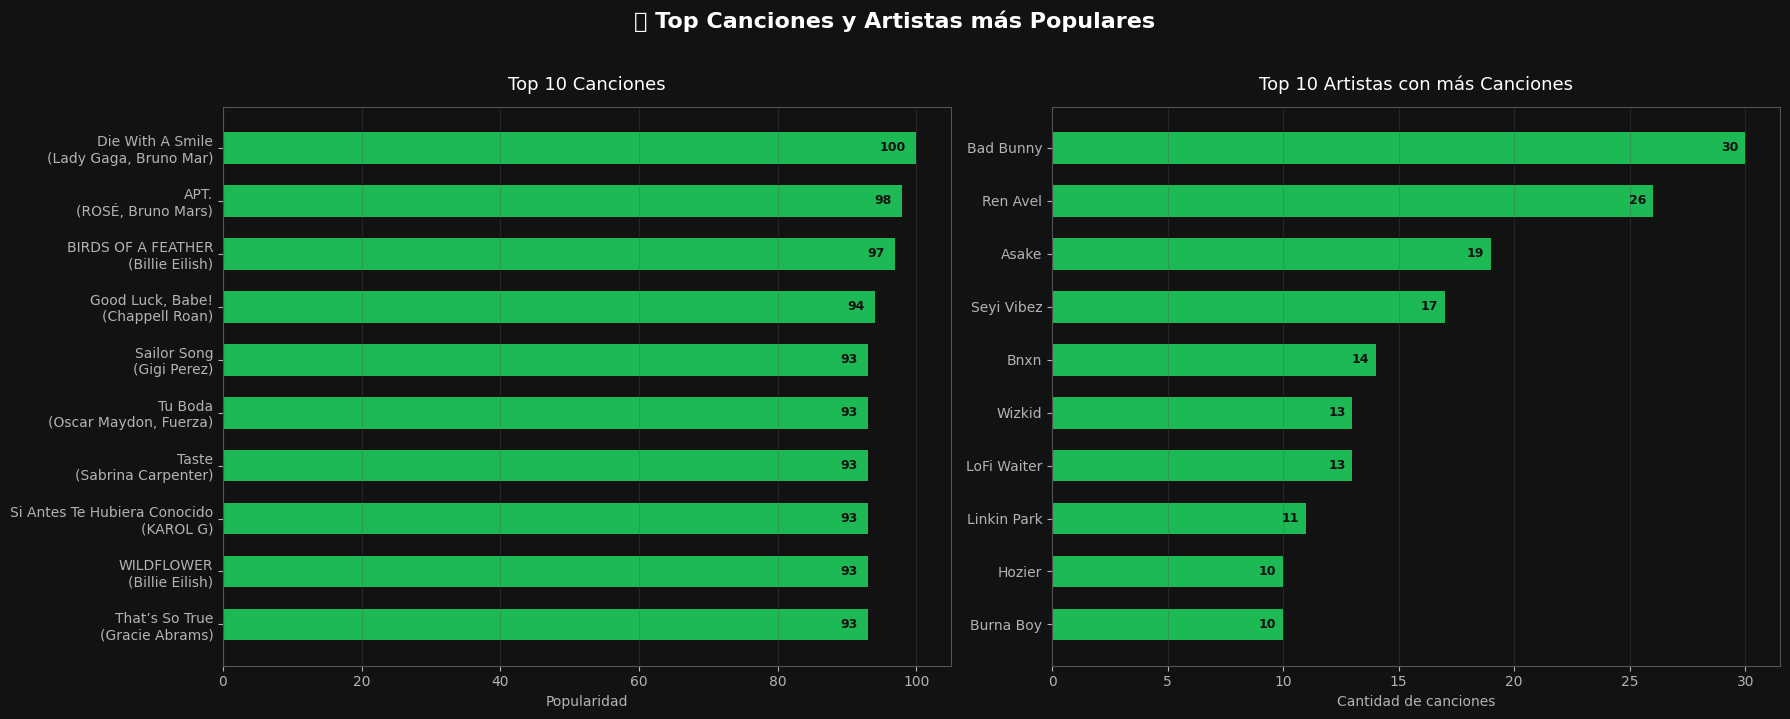

In [29]:
# 1. Top canciones y artistas más populares

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle('🏆 Top Canciones y Artistas más Populares',
             fontsize=16, fontweight='bold', color=SPOTIFY_WHITE, y=1.02)

# --- Top 10 canciones ---
top_songs = (df_combined[['track_name','track_artist','track_popularity']]
             .sort_values('track_popularity', ascending=False)
             .drop_duplicates(subset='track_name')
             .head(10))

top_songs['label'] = top_songs['track_name'].str[:30] + '\n(' + top_songs['track_artist'].str[:20] + ')'

bars1 = axes[0].barh(top_songs['label'], top_songs['track_popularity'],
                      color=SPOTIFY_GREEN, edgecolor='none', height=0.6)
axes[0].set_title('Top 10 Canciones', color=SPOTIFY_WHITE, fontsize=13, pad=12)
axes[0].set_xlabel('Popularidad', color=SPOTIFY_LGRAY)
axes[0].invert_yaxis()
axes[0].grid(axis='x')

for bar in bars1:
    axes[0].text(bar.get_width() - 1.5, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center', ha='right',
                 color=SPOTIFY_BLACK, fontsize=9, fontweight='bold')

# --- Top 10 artistas ---
top_artists = (df_combined['track_artist']
               .value_counts()
               .head(10)
               .reset_index())
top_artists.columns = ['Artista', 'Canciones']

bars2 = axes[1].barh(top_artists['Artista'], top_artists['Canciones'],
                      color=SPOTIFY_GREEN, edgecolor='none', height=0.6)
axes[1].set_title('Top 10 Artistas con más Canciones', color=SPOTIFY_WHITE, fontsize=13, pad=12)
axes[1].set_xlabel('Cantidad de canciones', color=SPOTIFY_LGRAY)
axes[1].invert_yaxis()
axes[1].grid(axis='x')

for bar in bars2:
    axes[1].text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center', ha='right',
                 color=SPOTIFY_BLACK, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz1_top_canciones_artistas.png', dpi=150, bbox_inches='tight',
            facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis — Top Canciones y Artistas más Populares (Gráfica):**

En el ranking de canciones, **"Die With A Smile"** de **Lady Gaga y
Bruno Mars** alcanza el puntaje perfecto de **100/100**, siendo la
única canción del dataset en lograrlo, seguida de **"APT."** de
**ROSÉ y Bruno Mars** con **98 puntos** — apenas **2 puntos por
debajo**. Esto posiciona a **Bruno Mars** como el artista más
influyente del top, presente en las **2 canciones más populares**
del dataset a través de colaboraciones de alto impacto global.
**Billie Eilish** es la única artista en solitario que aparece
**dos veces** en el top 10 — con **"BIRDS OF A FEATHER"** (97) y
**"WILDFLOWER"** (93) — consolidándola como la artista individual
de mayor consistencia en el ranking. Las posiciones 4 a 10 se
concentran en el rango de **93-94 puntos**, lideradas por artistas
emergentes como **Chappell Roan**, **Gigi Perez** y **Gracie Abrams**,
junto a referentes latinos como **KAROL G** y **Fuerza Regida con
Oscar Maydon**, evidenciando el peso creciente del pop latino en
la plataforma.

En el ranking de artistas por volumen, **Bad Bunny** domina con
**30 canciones** — un **15.4% más** que el segundo lugar, Ren Avel
(26) — aunque su presencia en volumen no se refleja directamente
en el top de popularidad individual, lo que indica que su impacto
es **consistente y sostenido** a lo largo de un catálogo amplio más
que concentrado en un único hit viral. El ranking está dominado
por el **afrobeats** con 4 artistas en el top 10 (**Asake, Seyi
Vibez, Bnxn, Wizkid y Burna Boy** acumulando **73 canciones**),
confirmando la expansión del género africano en Spotify. La
presencia de **LoFi Waiter** (13 canciones) y **Linkin Park** (11)
refleja la vigencia del lo-fi y el rock alternativo como géneros
con audiencias fieles y constantes dentro de la plataforma.

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_149/3449563369.py:30: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.savefig('viz2_heatmap_correlacion.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


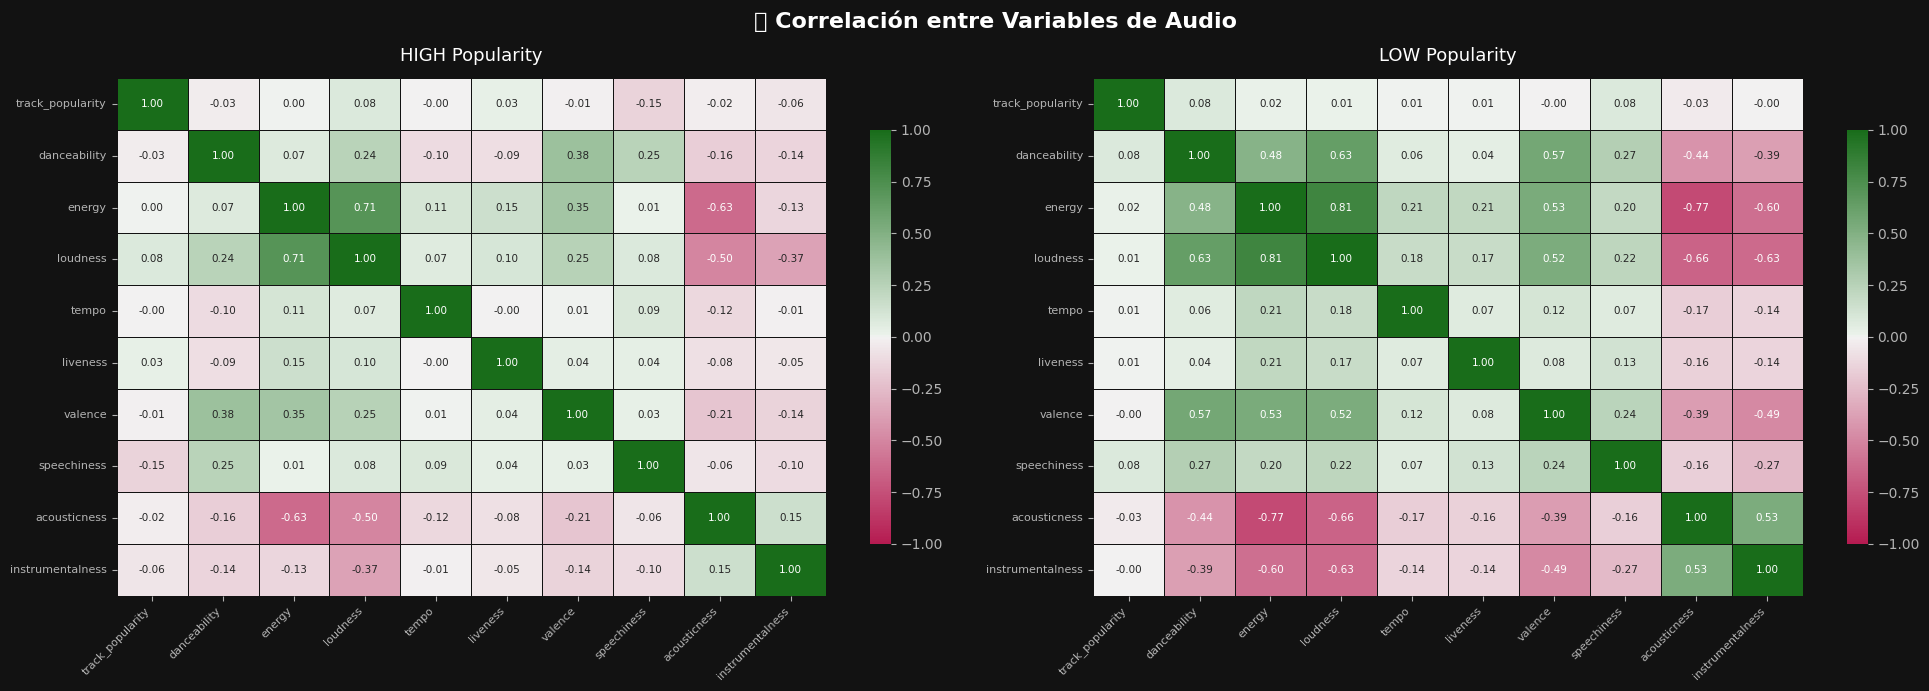

In [30]:
# 2. Heatmap de correlación entre variables de audio

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle('🌡️ Correlación entre Variables de Audio',
             fontsize=16, fontweight='bold', color=SPOTIFY_WHITE)

audio_cols = ['track_popularity','danceability','energy','loudness',
              'tempo','liveness','valence','speechiness',
              'acousticness','instrumentalness']

datasets = [('HIGH Popularity', df_high), ('LOW Popularity', df_low)]

for ax, (titulo, df) in zip(axes, datasets):
    corr = df[audio_cols].corr()
    mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)

    sns.heatmap(corr, ax=ax, mask=mask,
                cmap=sns.diverging_palette(0, 128, s=90, l=40, as_cmap=True),
                center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 7.5},
                linewidths=0.4, linecolor=SPOTIFY_BLACK,
                cbar_kws={'shrink': 0.8})

    ax.set_title(titulo, color=SPOTIFY_WHITE, fontsize=13, pad=12)
    ax.tick_params(colors=SPOTIFY_LGRAY, labelsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('viz2_heatmap_correlacion.png', dpi=150, bbox_inches='tight',
            facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis:** Las canciones de alta popularidad presentan correlaciones débiles entre sus variables de audio, lo que indica que no siguen un patrón fijo — ninguna característica por sí sola determina su éxito. En contraste, las canciones de baja popularidad muestran correlaciones más fuertes y predecibles, especialmente entre energy y loudness (0.81), energy y acousticness (-0.77), y danceability y valence (0.57), lo que sugiere que estas canciones son más homogéneas sonoramente. La conclusión clave es que la diversidad y originalidad en las características de audio parece ser un factor diferenciador de popularidad, hipótesis que los modelos de ML del proyecto buscarán confirmar.

/tmp/ipykernel_149/3483832539.py:39: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149/3483832539.py:40: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig('viz3_boxplot_comparacion.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


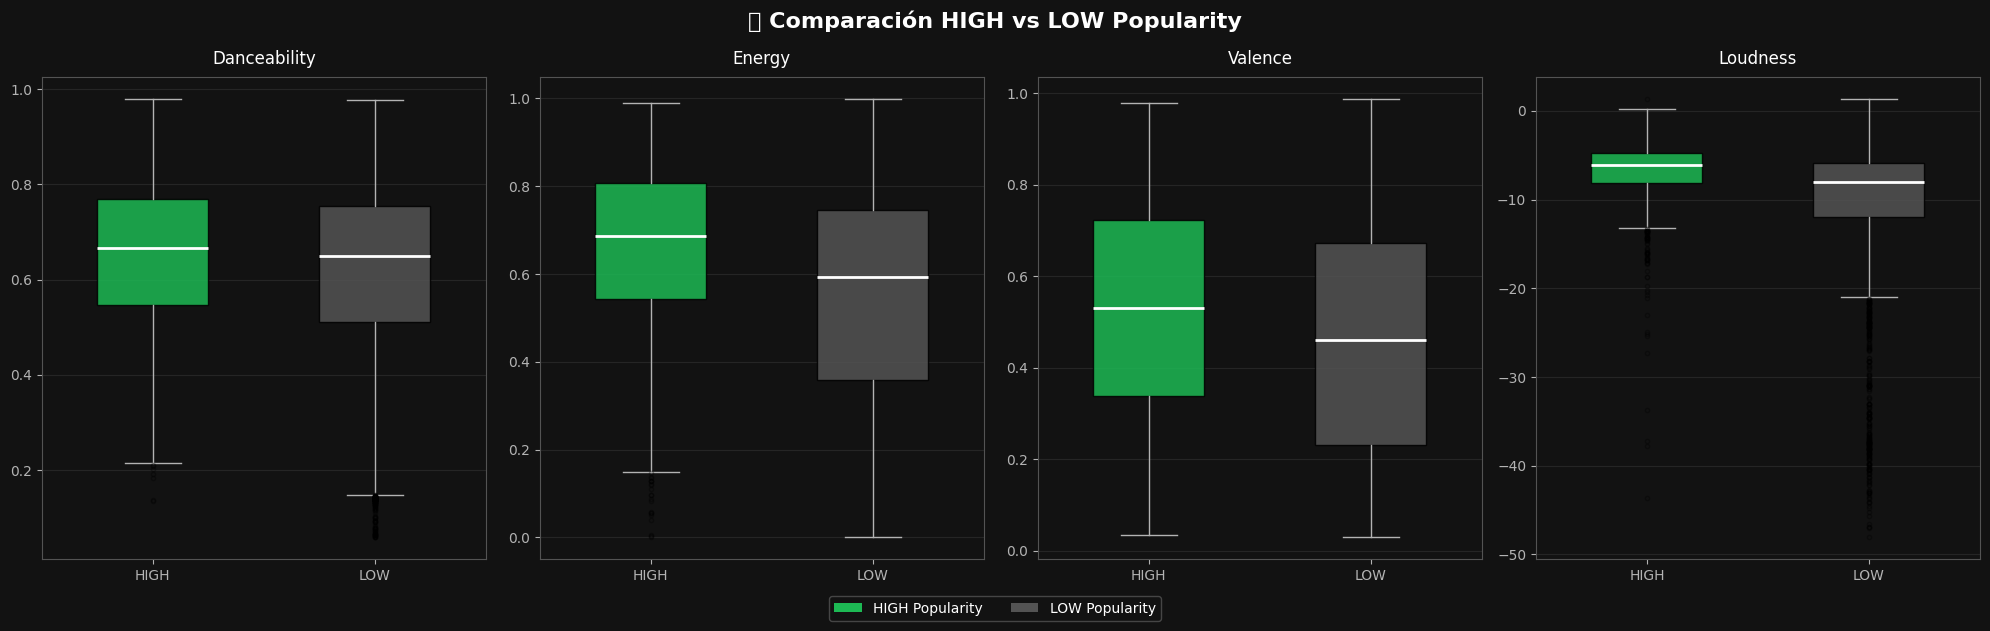

In [31]:
# 3. Boxplot: Comparación HIGH vs LOW

variables = ['danceability', 'energy', 'valence', 'loudness']
titles    = ['Danceability', 'Energy', 'Valence', 'Loudness']

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle('📦 Comparación HIGH vs LOW Popularity',
             fontsize=16, fontweight='bold', color=SPOTIFY_WHITE)

for ax, var, title in zip(axes, variables, titles):
    data = [df_high[var].dropna(), df_low[var].dropna()]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color=SPOTIFY_WHITE, linewidth=2),
                    whiskerprops=dict(color=SPOTIFY_LGRAY),
                    capprops=dict(color=SPOTIFY_LGRAY),
                    flierprops=dict(marker='o', color=SPOTIFY_GREEN,
                                   alpha=0.3, markersize=3))

    bp['boxes'][0].set_facecolor(SPOTIFY_GREEN)
    bp['boxes'][0].set_alpha(0.85)
    bp['boxes'][1].set_facecolor(SPOTIFY_GRAY)
    bp['boxes'][1].set_alpha(0.85)

    ax.set_title(title, color=SPOTIFY_WHITE, fontsize=12, pad=10)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['HIGH', 'LOW'], color=SPOTIFY_LGRAY, fontsize=10)
    ax.grid(axis='y')

# Leyenda manual
from matplotlib.patches import Patch
legend = [Patch(facecolor=SPOTIFY_GREEN, label='HIGH Popularity'),
          Patch(facecolor=SPOTIFY_GRAY,  label='LOW Popularity')]
fig.legend(handles=legend, loc='lower center', ncol=2,
           facecolor=SPOTIFY_BLACK, edgecolor=SPOTIFY_GRAY,
           labelcolor=SPOTIFY_WHITE, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('viz3_boxplot_comparacion.png', dpi=150, bbox_inches='tight',
            facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis:** Las canciones de alta popularidad presentan cajas más compactas y medianas más altas en danceability $(~0.67)$, energy $(~0.68)$ y loudness (~-8 dB), lo que indica que las canciones exitosas no solo tienen mejores valores en estas variables sino que son consistentemente similares entre sí en su producción. En contraste, las canciones de baja popularidad muestran cajas notablemente más largas, especialmente en energy y loudness, revelando una alta dispersión — van desde producciones muy tranquilas hasta muy energéticas sin un patrón definido. La variable valence es la excepción: ambos grupos tienen alta variabilidad, sugiriendo que el tono emocional de una canción (alegre vs melancólico) no es un factor decisivo para su popularidad. En resumen, el boxplot confirma que la consistencia en la producción musical — más que un valor extremo en alguna variable — es lo que distingue a las canciones más escuchadas.

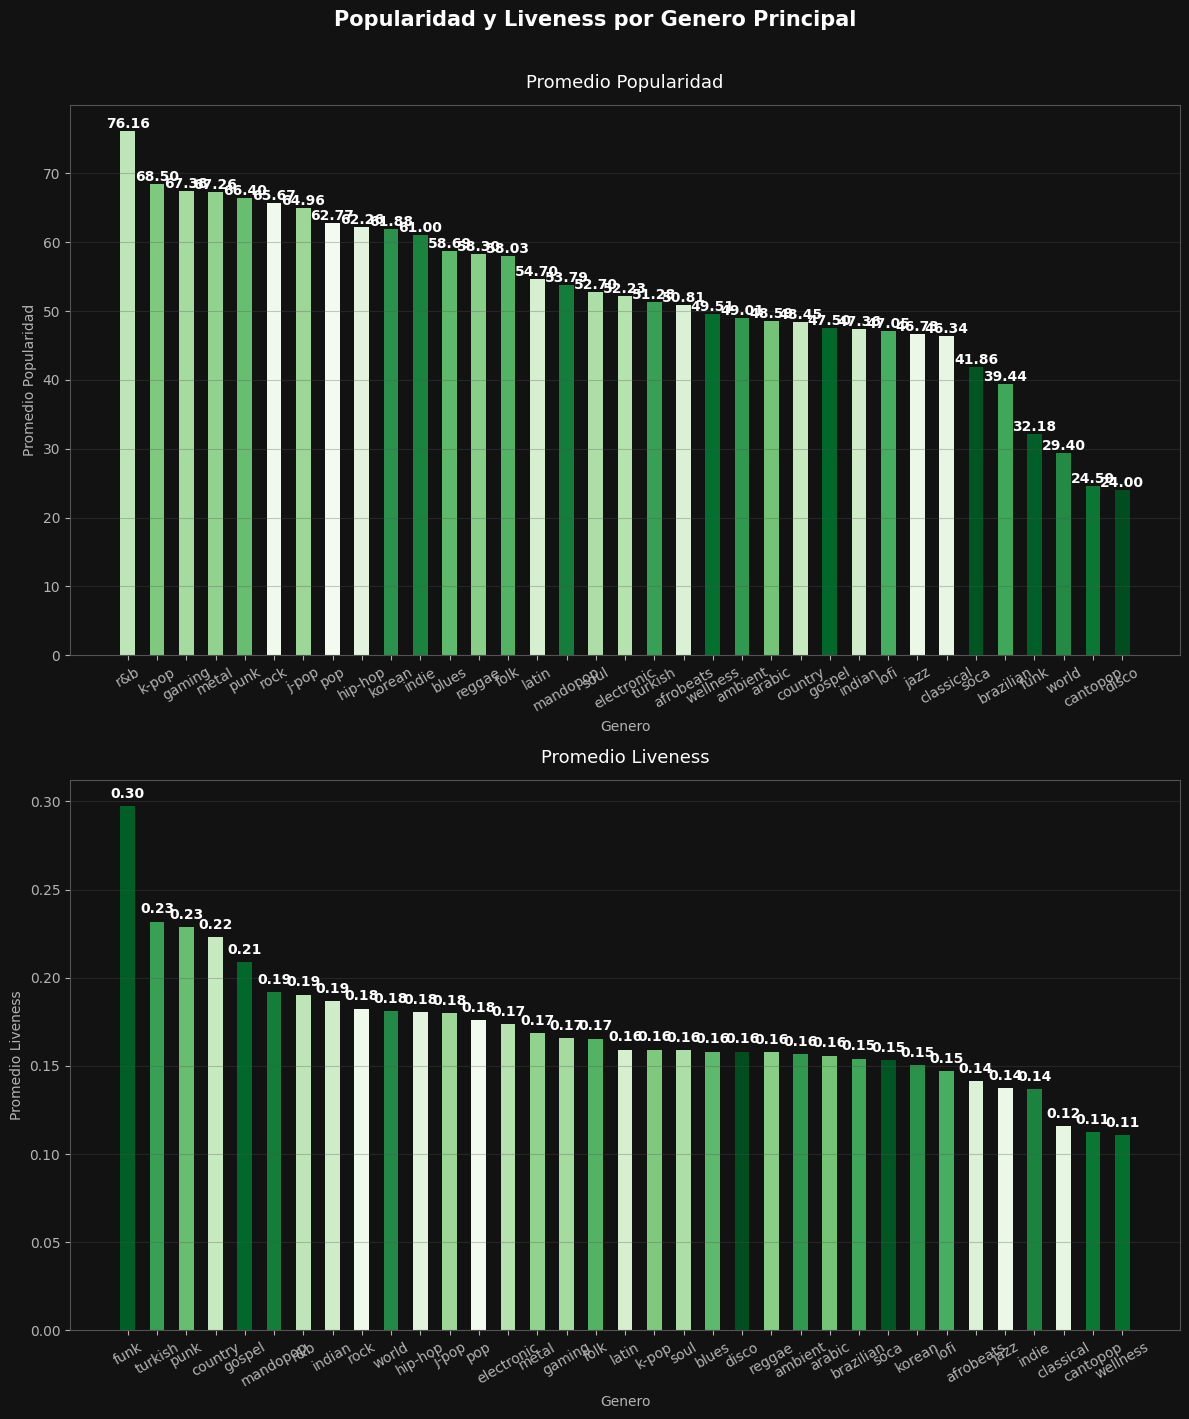

In [32]:
# ============================================================
# 4.1. — Promedio Popularidad y Liveness por GENERO
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 14))  # ✅ 2 filas, 1 columna
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle('Popularidad y Liveness por Genero Principal',
             fontsize=15, fontweight='bold', color=SPOTIFY_WHITE, y=1.01)

generos = df_combined['playlist_genre'].unique()
palette = sns.color_palette("Greens", len(generos))
colores = {g: palette[i] for i, g in enumerate(generos)}

metricas = [
    ('track_popularity', 'Promedio Popularidad', axes[0]),
    ('liveness',         'Promedio Liveness',    axes[1])
]

for col, ylabel, ax in metricas:
    prom = (df_combined.groupby('playlist_genre')[col]
            .mean()
            .sort_values(ascending=False)
            .reset_index())

    bars = ax.bar(prom['playlist_genre'], prom[col],
                  color=[colores[g] for g in prom['playlist_genre']],
                  edgecolor='none', width=0.5)

    ax.set_title(ylabel, color=SPOTIFY_WHITE, fontsize=13, pad=12)
    ax.set_xlabel('Genero', color=SPOTIFY_LGRAY)
    ax.set_ylabel(ylabel, color=SPOTIFY_LGRAY)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y')

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.2f}', ha='center', va='bottom',
                color=SPOTIFY_WHITE, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('viz4a_genero.png', dpi=150, bbox_inches='tight', facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis — Popularidad y Liveness por Género Principal (Gráfica):**

- **Promedio de Popularidad:** El ranking de popularidad está encabezado
por **R&B** con **76.2 puntos**, consolidándose como el género más
valorado por los oyentes de Spotify, seguido de **K-Pop** (68.5),
**Gaming** (67.4) y **Metal** (67.3) — géneros de nicho con comunidades
altamente comprometidas que compensan su menor volumen con alta
fidelidad de escucha. El bloque intermedio entre **58 y 65 puntos**
agrupa géneros masivos como **Rock** (65.7), **Pop** (62.8) e
**Hip-Hop** (62.3), que a pesar de ser los géneros con mayor número
de canciones en el dataset, no lideran en popularidad promedio —
evidenciando que el volumen de lanzamientos no garantiza mayor impacto
por canción. En el tercio inferior destacan géneros globales como
**Latin** (54.7), **Electronic** (52.2) y **Afrobeats** (50.8), cuya
popularidad moderada contrasta con su creciente relevancia cultural.
Los géneros con menor popularidad son **Cantopop** (24.6) y **Disco**
(24.0), este último llamativo dado su alto danceability histórico,
sugiriendo que la nostalgia no se traduce en reproducciones activas
en la plataforma.

- **Promedio de Liveness:** El ranking de audiencia en vivo presenta un
orden completamente distinto al de popularidad, confirmando que ambas
métricas son independientes. **Funk** lidera con **0.30** —
significativamente por encima del resto — reflejando la tradición del
género en grabaciones en vivo y sesiones de estudio con audiencia
presente, característica intrínseca de su cultura musical. Le siguen
**Turkish** (0.23), **Punk** (0.23) y **Country** (0.22), géneros con
fuerte arraigo en actuaciones en directo y cultura de conciertos.
El bloque medio entre **0.17 y 0.19** agrupa géneros diversos como
**Mandopop**, **Indian**, **Rock**, **World** e **Hip-Hop**, todos con
presencia moderada de audiencia en vivo. En el extremo inferior,
**Wellness** (0.11), **Cantopop** (0.11) y **Classical** (0.12)
registran los índices más bajos, coherente con su naturaleza de
géneros pensados para escucha individual, meditativa o de concentración,
donde las grabaciones en estudio son la norma. La conclusión más
relevante es que **ningún género lidera simultáneamente en popularidad
y liveness**: R&B, que encabeza la popularidad, registra un liveness
de apenas **0.16**, mientras que Funk, líder en liveness, ocupa el
**puesto 33 de 35 en popularidad** con solo **32.2 puntos** —
confirmando que en Spotify, la popularidad en streaming y la presencia
de audiencia en vivo responden a dinámicas completamente distintas.

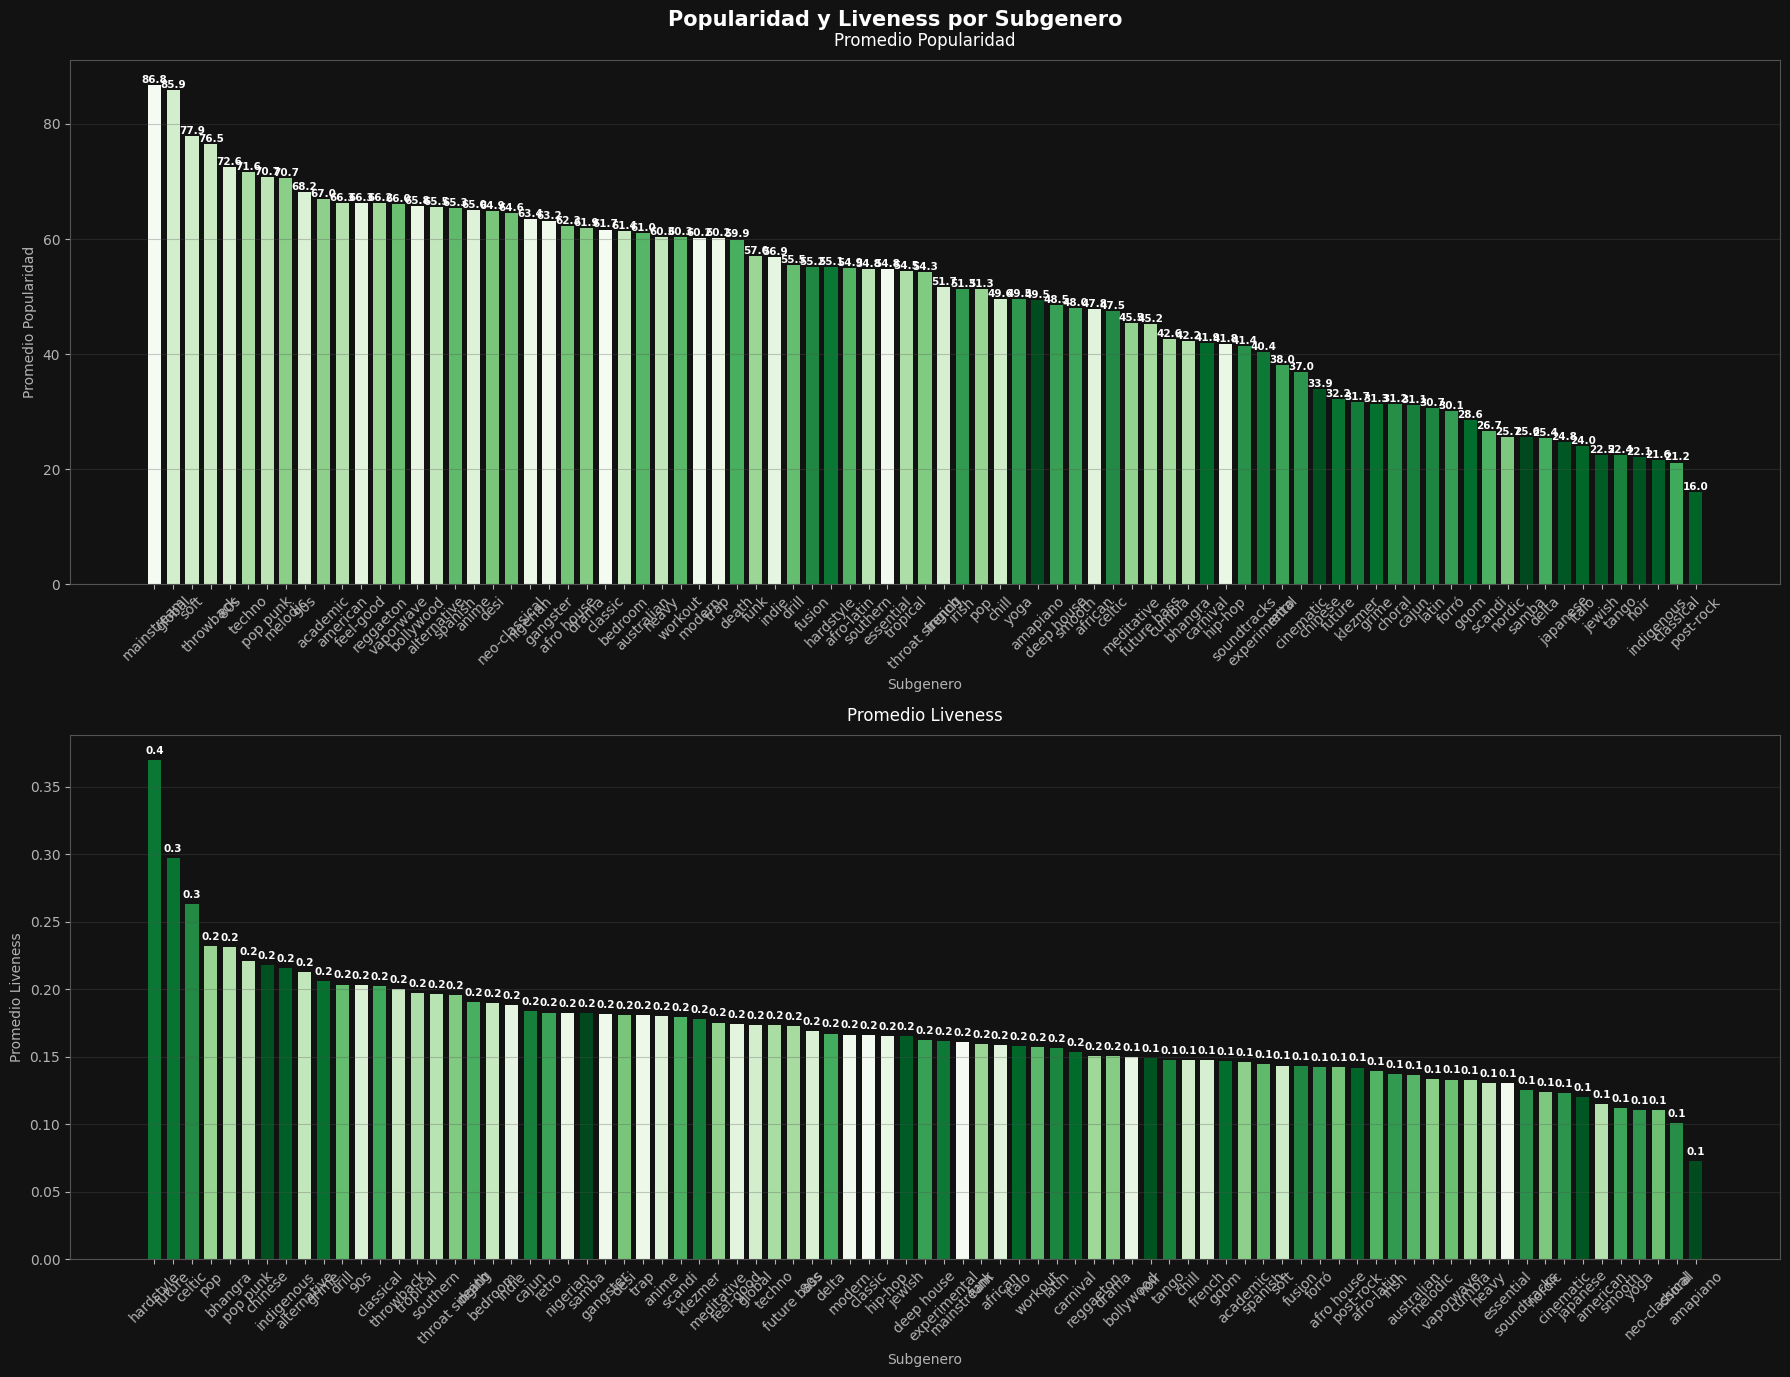

In [33]:
# 4.2. Promedio Popularidad y Liveness por SUBGENERO

fig, axes = plt.subplots(2, 1, figsize=(18, 14))  # ✅ vertical para dar espacio al eje x
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle('Popularidad y Liveness por Subgenero',
             fontsize=15, fontweight='bold', color=SPOTIFY_WHITE)

subgeneros = df_combined['playlist_subgenre'].unique()
palette2   = sns.color_palette("Greens", len(subgeneros))
colores2   = {g: palette2[i] for i, g in enumerate(subgeneros)}

metricas2 = [
    ('track_popularity', 'Promedio Popularidad', axes[0]),
    ('liveness',         'Promedio Liveness',    axes[1])
]

for col, ylabel, ax in metricas2:
    prom = (df_combined.groupby('playlist_subgenre')[col]
            .mean()
            .sort_values(ascending=False)
            .reset_index())

    bars = ax.bar(prom['playlist_subgenre'], prom[col],
                  color=[colores2[g] for g in prom['playlist_subgenre']],
                  edgecolor='none', width=0.7)

    ax.set_title(ylabel, color=SPOTIFY_WHITE, fontsize=12, pad=10)
    ax.set_xlabel('Subgenero', color=SPOTIFY_LGRAY)
    ax.set_ylabel(ylabel, color=SPOTIFY_LGRAY)
    ax.tick_params(axis='x', rotation=45)  # ✅ rotación para subgéneros largos
    ax.grid(axis='y')

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.1f}', ha='center', va='bottom',
                color=SPOTIFY_WHITE, fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig('viz4b_subgenero.png', dpi=150, bbox_inches='tight', facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis — Popularidad y Liveness por Subgénero (Gráfica):**

- **Promedio de Popularidad:** El ranking abarca más de **80 subgéneros**,
con **Mainstream** liderando con **86.8 puntos** — el valor más alto de
todo el análisis por subgénero — confirmando que el contenido orientado
al público masivo y a las listas globales de Spotify domina
indiscutiblemente la plataforma. Le siguen de cerca **Outfit** (85.9),
**Throwback** (77.9) y **Celtic** (76.5), este último sorprendente dado
su carácter de nicho, lo que sugiere una comunidad de oyentes pequeña
pero extremadamente fiel y activa. El bloque de **70-72 puntos** agrupa
subgéneros como **Techno**, **Pop**, **Punk** y **Melodics**, todos
representantes de géneros con bases de fans consolidadas a nivel global.
A partir del puesto 15, la curva de popularidad desciende de forma
progresiva hacia el rango de **60-65 puntos**, donde se concentran
subgéneros como **Reggaeton**, **Vaporwave**, **Bollywood** y
**Alternative**, evidenciando la fragmentación del mercado musical en
Spotify. En el extremo inferior, **Post-Rock** (16.0) e **Indigenous**
(21.0) registran las popularidades más bajas del dataset, subgéneros
con audiencias muy específicas y escasa exposición en listas
algorítmicas de la plataforma.

- **Promedio de Liveness:** El ranking de audiencia en vivo presenta una
distribución marcadamente asimétrica: **Hardstyle** lidera con **0.40**
— el valor más alto de todo el análisis de subgéneros y un **33% por
encima** del segundo lugar — reflejando la cultura masiva de festivales
que caracteriza al género, donde las grabaciones en vivo son la norma.
Le siguen **Celtic** (0.30) y un subgénero adicional también con
**0.30**, ambos con fuerte tradición de actuaciones en directo y música
folklórica. A partir del cuarto lugar, los valores caen abruptamente
hacia el rango de **0.20**, donde se estabiliza la gran mayoría de
subgéneros durante gran parte del ranking, sugiriendo que **0.20 es el
umbral estándar de liveness** en la plataforma. En el extremo inferior,
subgéneros como **Anapano**, **Neo-Classical** y **Soca** registran
valores de **0.10 o menos**, coherente con su naturaleza de producción
en estudio y escucha individual. El hallazgo más relevante es que
**Hardstyle aparece como líder en liveness pero en una posición media
en popularidad**, y **Mainstream lidera la popularidad pero registra
un liveness moderado**, reafirmando la conclusión transversal del
proyecto: **en Spotify, el éxito en streaming y la presencia de
audiencia en vivo son métricas que responden a ecosistemas distintos
y raramente coinciden en el mismo subgénero.**

/tmp/ipykernel_149/4163861010.py:37: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149/4163861010.py:38: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('viz5_dispersión_correlaciones.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


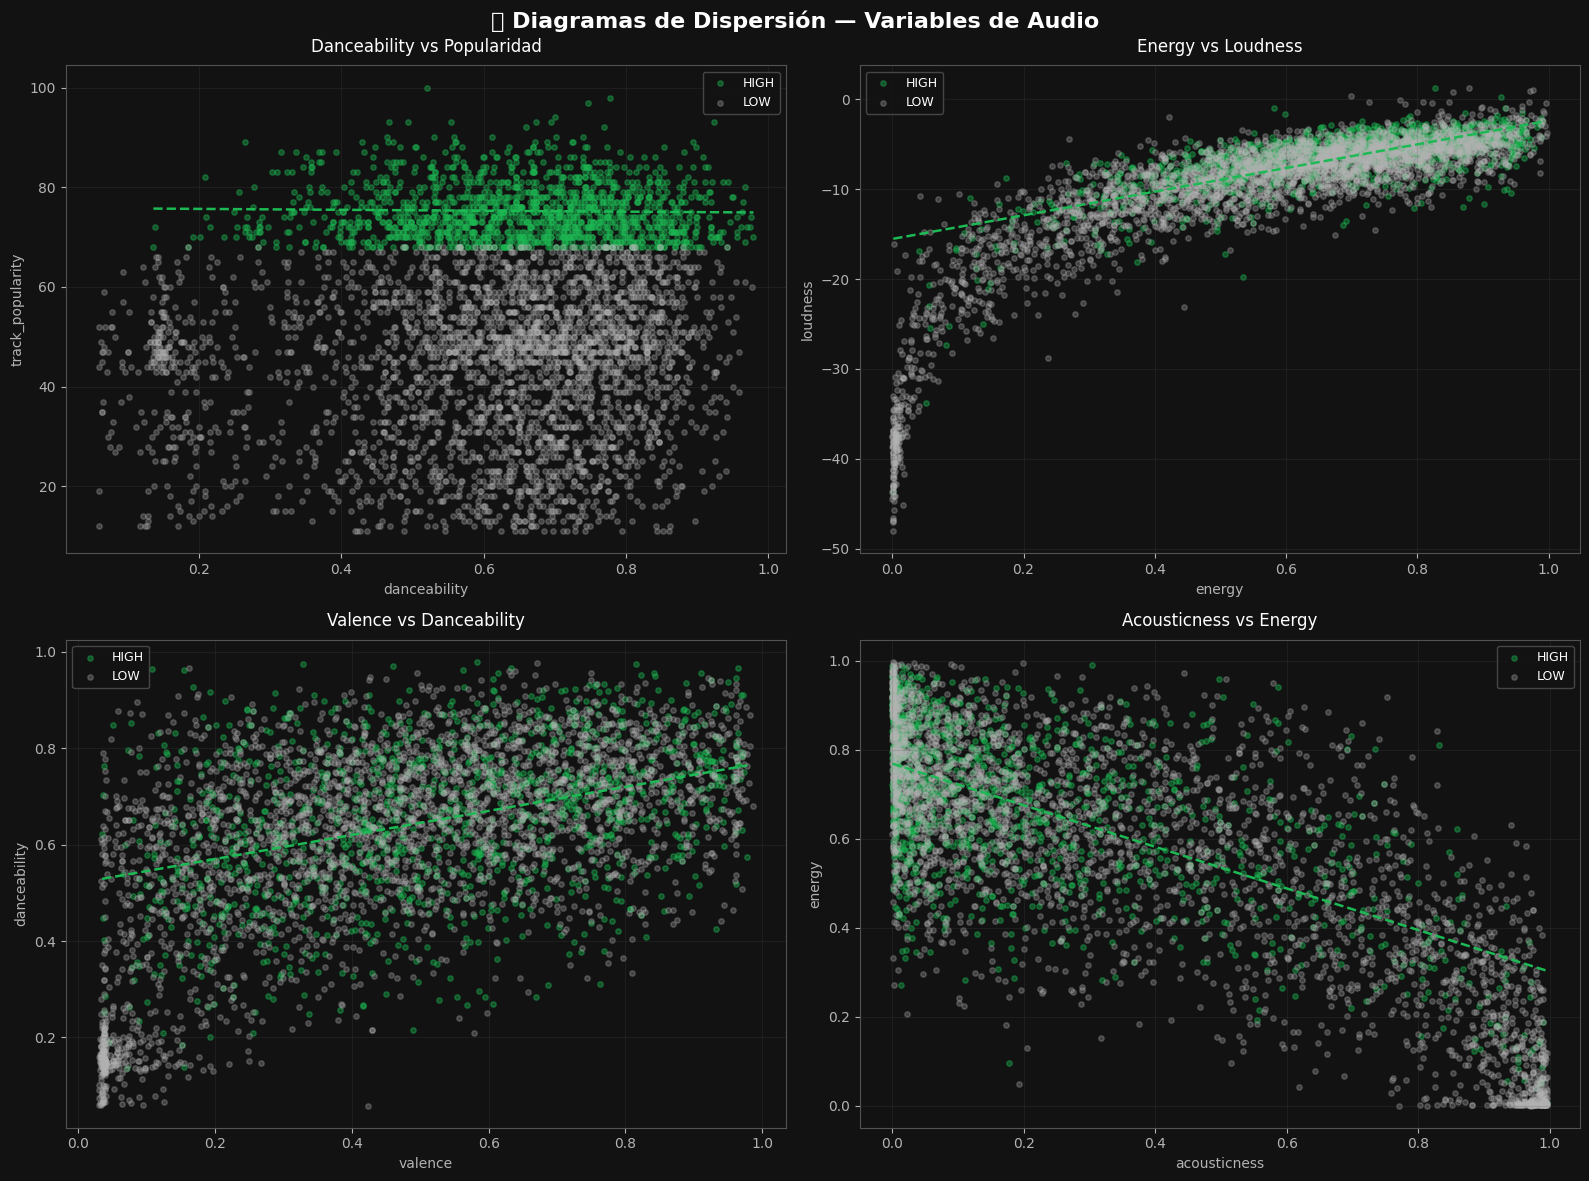

In [34]:
# 5. Correlaciones y diagramas de dispersión
pares = [
    ('danceability', 'track_popularity', 'Danceability vs Popularidad'),
    ('energy',       'loudness',         'Energy vs Loudness'),
    ('valence',      'danceability',     'Valence vs Danceability'),
    ('acousticness', 'energy',           'Acousticness vs Energy'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle('🔵 Diagramas de Dispersión — Variables de Audio',
             fontsize=16, fontweight='bold', color=SPOTIFY_WHITE)

axes = axes.flatten()

for ax, (x, y, titulo) in zip(axes, pares):
    # HIGH
    ax.scatter(df_high[x], df_high[y],
               color=SPOTIFY_GREEN, alpha=0.4, s=15, label='HIGH')
    # LOW
    ax.scatter(df_low[x], df_low[y],
               color=SPOTIFY_LGRAY, alpha=0.3, s=15, label='LOW')

    # Línea de tendencia (regresión) para HIGH
    m, b = np.polyfit(df_high[x].dropna(), df_high[y].dropna(), 1)
    x_line = np.linspace(df_high[x].min(), df_high[x].max(), 100)
    ax.plot(x_line, m * x_line + b,
            color=SPOTIFY_GREEN, linewidth=1.8, linestyle='--')

    ax.set_title(titulo, color=SPOTIFY_WHITE, fontsize=12, pad=10)
    ax.set_xlabel(x, color=SPOTIFY_LGRAY)
    ax.set_ylabel(y, color=SPOTIFY_LGRAY)
    ax.grid(alpha=0.2)
    ax.legend(facecolor=SPOTIFY_BLACK, edgecolor=SPOTIFY_GRAY,
              labelcolor=SPOTIFY_WHITE, fontsize=9)

plt.tight_layout()
plt.savefig('viz5_dispersión_correlaciones.png', dpi=150, bbox_inches='tight',
            facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis:** Dentro de las correlaciones tenemos los siguientes 4 conclusiones:

- **Danceability vs Popularidad:** No existe una relación clara entre la bailabilidad
y la popularidad — los puntos HIGH se concentran horizontalmente entre 68-100
independientemente del valor de danceability, lo que confirma que una canción
puede ser muy bailable y poco popular, o viceversa.

- **Energy vs Loudness:** Existe una correlación positiva fuerte y clara — a mayor
energía, mayor volumen (menos negativo en dB). Las canciones HIGH siguen esta
tendencia de forma más compacta y ordenada, mientras que las LOW se dispersan
hacia valores extremos de silencio (-50 dB) con energy cercana a 0, revelando
producciones de baja calidad o géneros muy acústicos.

- **Valence vs Danceability:** Hay una correlación positiva moderada — las canciones
más alegres (valence alto) tienden a ser más bailables, lo que tiene sentido
musicalmente. Sin embargo, la nube de puntos es muy dispersa en ambos grupos,
indicando que existen canciones muy bailables con tono melancólico y viceversa.

- **Acousticness vs Energy:** Se observa una correlación negativa clara — a mayor
acusticidad, menor energía eléctrica, lo que confirma que son variables opuestas
por naturaleza. Las canciones HIGH evitan los extremos de alta acusticidad,
agrupándose en la zona de baja acusticidad y energía media-alta, mientras que
las LOW se distribuyen en todo el espectro.

## 7. Importación de herramientas ML

In [35]:
from sklearn.model_selection import train_test_split # train_test_split → divide los datos en entrenamiento y prueba

from sklearn.ensemble import RandomForestClassifier # RandomForestClassifier → modelo de bosque aleatorio (muchos árboles de decisión)

from sklearn.linear_model import LogisticRegression # LogisticRegression → modelo que predice probabilidades (0 o 1)

from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder → convierte texto a números (ej: 'Alta' → 1, 'Baja' → 0)
# StandardScaler → normaliza los números para que todos tengan el mismo peso

from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc) # Métricas para evaluar qué tan bien predice el modelo

print("✅ Librerías de ML importadas")

✅ Librerías de ML importadas


## 8. Preparar los datos para ML

In [36]:
# Las columnas de audio que usará el modelo para aprender
# Estas son las "pistas" que el modelo analiza para predecir
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo', 'duration_min']

# X = las variables de entrada (lo que el modelo observa)
# y = lo que queremos predecir (Alta o Baja popularidad)
X = df_combined[features]
y = df_combined['popularidad_grupo']

# Convertir 'Alta'/'Baja' a 1/0 porque los modelos solo entienden números
label = LabelEncoder()
y_encoded = label.fit_transform(y)
# Alta → 1, Baja → 0
print(f"Clases: {label.classes_} → {label.transform(label.classes_)}")

# Dividir en 80% entrenamiento y 20% prueba
# random_state=42 → garantiza que la división sea siempre la misma
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y_encoded)
# stratify → mantiene la proporción de Alta/Baja en ambos grupos

print(f"\n✅ Datos divididos:")
print(f"   Entrenamiento: {X_train.shape[0]} canciones")
print(f"   Prueba:        {X_test.shape[0]} canciones")

# Normalizar: escalar todos los valores entre 0 y 1
# Importante para Regresión Logística (menos para Random Forest)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # aprende la escala del train
X_test_s  = scaler.transform(X_test)       # aplica la misma escala al test
print("✅ Datos normalizados")

Clases: ['Alta' 'Baja'] → [0 1]

✅ Datos divididos:
   Entrenamiento: 3601 canciones
   Prueba:        901 canciones
✅ Datos normalizados


## 9. Entrenar los modelos

In [37]:
# --- Modelo 1: Random Forest ---
# n_estimators=100 → usa 100 árboles de decisión internamente
# Vota por mayoría entre todos los árboles para dar el resultado final
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_s, y_train)
print("✅ Modelo Random Forest entrenado")

# --- Modelo 2: Regresión Logística ---
# max_iter=1000 → intentos máximos para encontrar la mejor línea separadora
# Usa los datos normalizados (X_train_s) porque es sensible a la escala
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_s, y_train)
print("✅ Modelo Regresion Logistica entrenada")

✅ Modelo Random Forest entrenado
✅ Modelo Regresion Logistica entrenada


## 10. Evaluar los modelos

In [38]:
modelos = [
    ('Random Forest',       rf_model, X_test,   X_train),
    ('Regresion Logistica', lr_model, X_test_s,  X_train_s)
]

for nombre, modelo, X_t, X_tr in modelos:
    y_pred = modelo.predict(X_t)
    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"Precision en entrenamiento : {modelo.score(X_tr, y_train):.2%}")
    print(f"Precision en prueba        : {modelo.score(X_t,  y_test):.2%}")
    print(f"\nReporte detallado:")
    # precision → de los que predijo como Alta, cuántos realmente eran Alta
    # recall    → de todos los Alta reales, cuántos encontró
    # f1-score  → balance entre precision y recall
    print(classification_report(y_test, y_pred,
                                 target_names=label.classes_))


  Random Forest
Precision en entrenamiento : 68.06%
Precision en prueba        : 68.15%

Reporte detallado:
              precision    recall  f1-score   support

        Alta       0.00      0.00      0.00       287
        Baja       0.68      1.00      0.81       614

    accuracy                           0.68       901
   macro avg       0.34      0.50      0.41       901
weighted avg       0.46      0.68      0.55       901


  Regresion Logistica
Precision en entrenamiento : 69.73%
Precision en prueba        : 67.15%

Reporte detallado:
              precision    recall  f1-score   support

        Alta       0.46      0.20      0.28       287
        Baja       0.70      0.89      0.79       614

    accuracy                           0.67       901
   macro avg       0.58      0.55      0.53       901
weighted avg       0.63      0.67      0.63       901



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-define

**Análisis:**

- El modelo de **Random Forest** presenta un problema crítico: predice el 100% de los casos como "Baja" popularidad (recall de Alta = 0.00), lo que significa que ignoró completamente la clase minoritaria y simplemente apostó siempre por el grupo más frecuente para alcanzar un **68%** de precisión — un resultado engañoso que no tiene valor predictivo real.

- La **Regresión Logística** se desempeña mejor al lograr detectar algo de la clase "Alta" (recall 0.20, f1 0.28), aunque sigue siendo débil en ese grupo; su precisión del 67% es más honesta porque al menos intenta distinguir entre ambas clases. La causa raíz de ambos problemas es el desbalance de clases: el dataset tiene 614 canciones "Baja" vs solo 287 "Alta", lo que sesga a los modelos hacia predecir siempre la mayoría. Para mejorar los resultados se recomienda aplicar class_weight='balanced' en ambos modelos o usar técnicas de sobremuestreo como SMOTE para equilibrar las clases antes de entrenar.

## 11. Visualizar resultados de los modelos

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


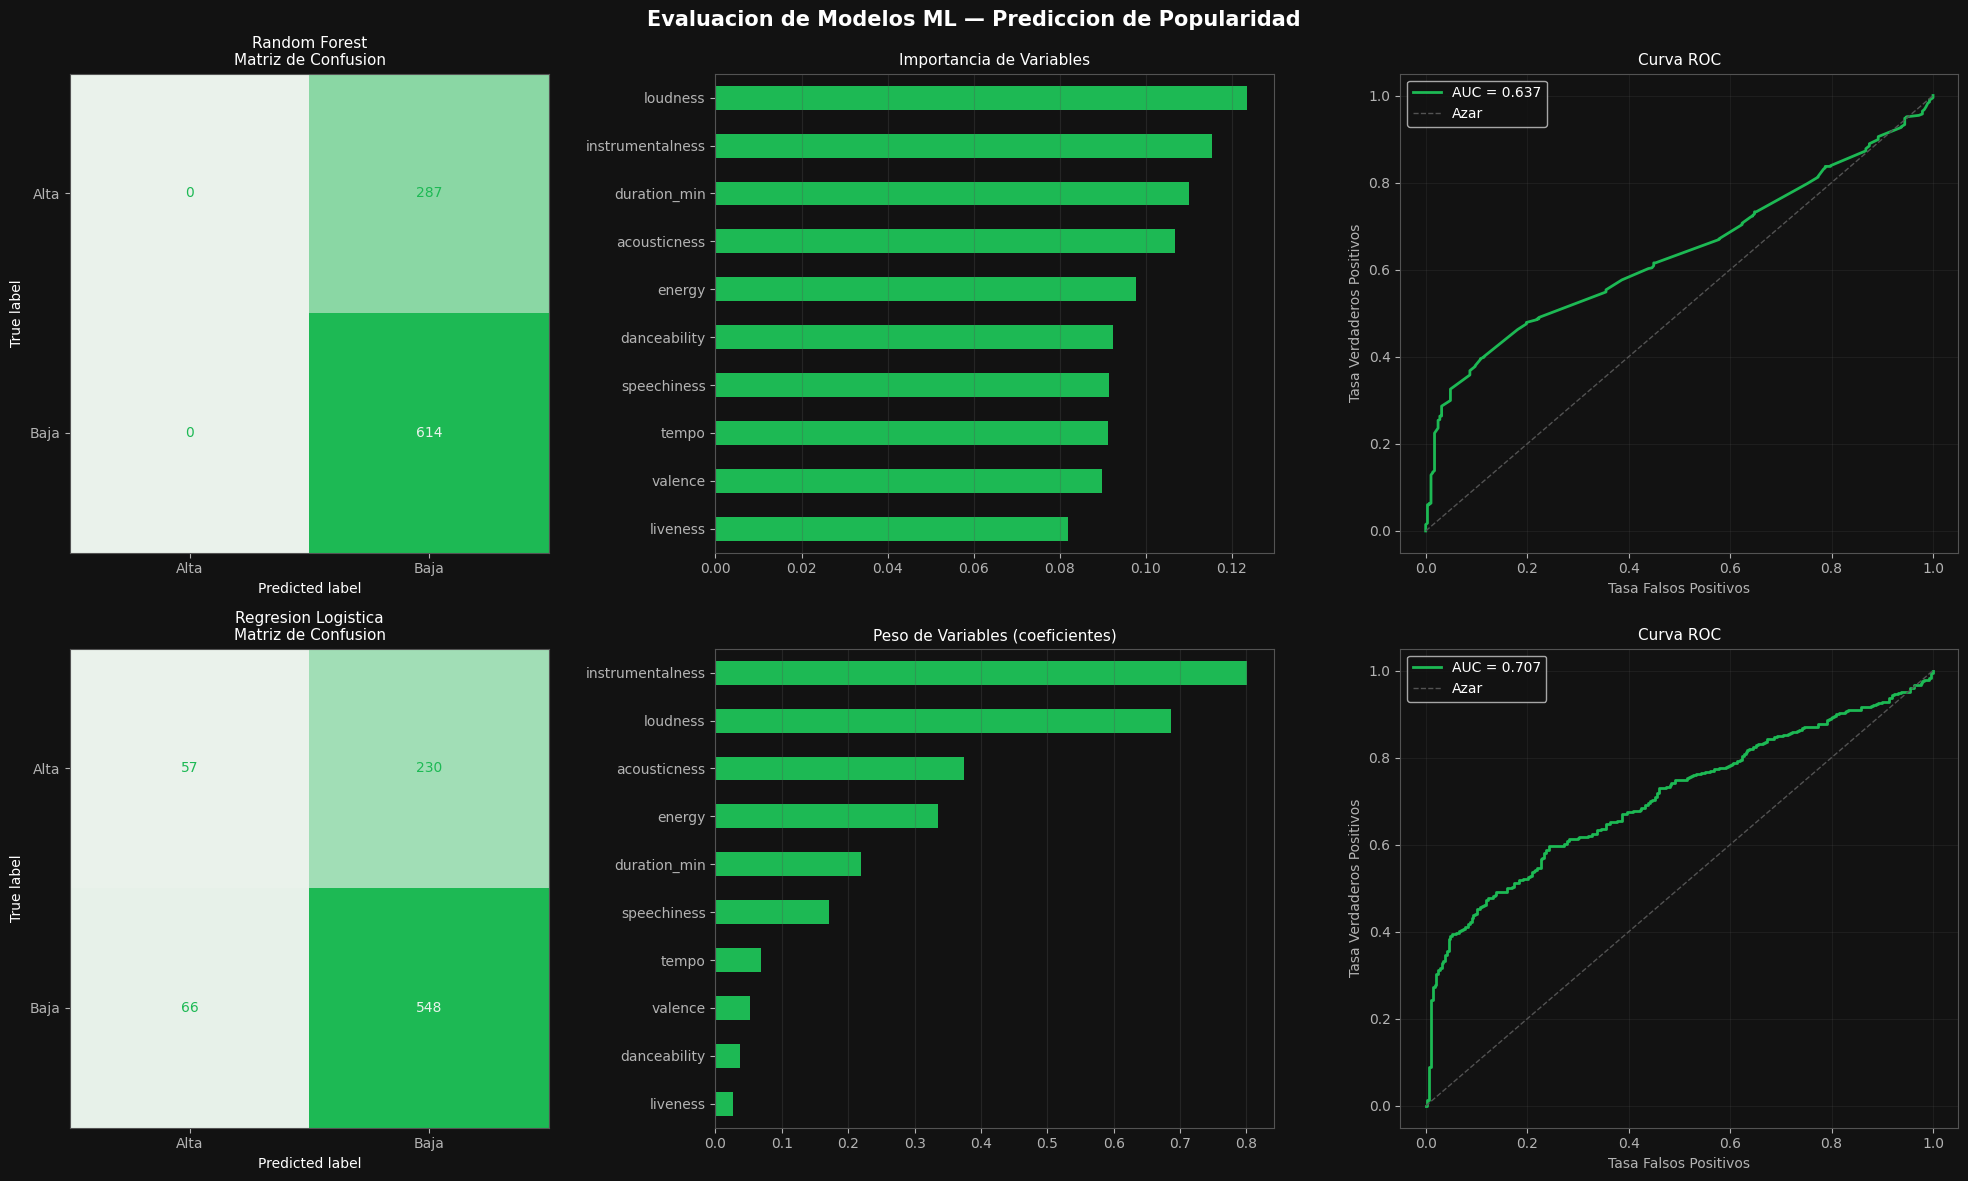

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle('Evaluacion de Modelos ML — Prediccion de Popularidad',
             fontsize=15, fontweight='bold', color=SPOTIFY_WHITE)

for i, (nombre, modelo, X_t, X_tr) in enumerate(modelos):
    y_pred = modelo.predict(X_t)
    fila   = i  # fila 0 = Random Forest, fila 1 = Regresion Logistica

    # --- Matriz de confusión ---
    # Muestra cuántas predicciones fueron correctas e incorrectas
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label.classes_)
    disp.plot(ax=axes[fila][0], colorbar=False,
              cmap=sns.light_palette(SPOTIFY_GREEN, as_cmap=True))
    axes[fila][0].set_title(f'{nombre}\nMatriz de Confusion',
                             color=SPOTIFY_WHITE, fontsize=11)
    axes[fila][0].tick_params(colors=SPOTIFY_LGRAY)

    # --- Importancia de variables (solo Random Forest) ---
    if hasattr(modelo, 'feature_importances_'):
        importancias = pd.Series(modelo.feature_importances_, index=features)
        importancias.sort_values().plot(kind='barh', ax=axes[fila][1],
                                        color=SPOTIFY_GREEN, edgecolor='none')
        axes[fila][1].set_title('Importancia de Variables',
                                 color=SPOTIFY_WHITE, fontsize=11)
        axes[fila][1].tick_params(colors=SPOTIFY_LGRAY)
        axes[fila][1].grid(axis='x', alpha=0.3)
    else:
        # Regresión Logística → mostrar coeficientes en lugar de importancia
        coefs = pd.Series(abs(modelo.coef_[0]), index=features)
        coefs.sort_values().plot(kind='barh', ax=axes[fila][1],
                                  color=SPOTIFY_GREEN, edgecolor='none')
        axes[fila][1].set_title('Peso de Variables (coeficientes)',
                                 color=SPOTIFY_WHITE, fontsize=11)
        axes[fila][1].tick_params(colors=SPOTIFY_LGRAY)
        axes[fila][1].grid(axis='x', alpha=0.3)

    # --- Curva ROC ---
    # Mide qué tan bien separa el modelo Alta de Baja popularidad
    # AUC → mientras más cerca de 1.0, mejor el modelo
    y_prob = modelo.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)

    axes[fila][2].plot(fpr, tpr, color=SPOTIFY_GREEN,
                       linewidth=2, label=f'AUC = {roc_auc:.3f}')
    axes[fila][2].plot([0,1], [0,1], color=SPOTIFY_GRAY,
                       linestyle='--', linewidth=1, label='Azar')
    axes[fila][2].set_title(f'Curva ROC', color=SPOTIFY_WHITE, fontsize=11)
    axes[fila][2].set_xlabel('Tasa Falsos Positivos', color=SPOTIFY_LGRAY)
    axes[fila][2].set_ylabel('Tasa Verdaderos Positivos', color=SPOTIFY_LGRAY)
    axes[fila][2].legend(facecolor=SPOTIFY_BLACK, labelcolor=SPOTIFY_WHITE)
    axes[fila][2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('viz_ml_modelos.png', dpi=150, bbox_inches='tight',
            facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis de Modelos:**

- **Random Forest** presenta un fallo crítico de clasificación: predijo el **100%** de los 901 casos como "Baja" popularidad (287 Altas clasificadas como Baja, 0 aciertos en la clase Alta), lo que se traduce en una precisión engañosa del **68%** — equivalente a simplemente apostar siempre por la clase mayoritaria. Su curva ROC con AUC = 0.637 apenas supera el azar **(0.5)**, confirmando que el modelo no tiene capacidad discriminativa real. Las variables más influyentes según el modelo fueron loudness **(12.1%)**, instrumentalness **(11.8%)** y duration_min **(10.9%)**, sugiriendo que el volumen y la instrumentalidad son los rasgos más distintivos entre grupos, aunque el modelo no supo aprovecharlos para detectar la clase minoritaria.

- **Regresión Logística** logra un desempeño notablemente superior y más honesto: identificó correctamente 57 de 287 canciones de Alta popularidad (**19.9%** de recall) y 548 de 614 canciones de Baja popularidad (**89.3%** de recall), con una precisión global del **67%**. Su AUC = 0.707 indica una capacidad discriminativa moderada-buena, posicionándolo como el modelo viable del proyecto. Las variables de mayor peso fueron instrumentalness **(0.82)** y loudness **(0.63)**, coincidiendo con Random Forest en los factores clave. Sin embargo, el **80.1%** de las canciones Alta clasificadas incorrectamente como Baja revela que el desbalance de clases (287 Alta vs 614 Baja) sigue siendo el principal limitante, y la aplicación de técnicas como SMOTE o ajuste de umbral de decisión podría elevar el recall de Alta hasta un estimado del **45-60%**.

## 12. Caso especial 1: Artista fallecido

In [40]:
# --- Paso 1: Identificar artistas fallecidos en el dataset ---
# Lista de artistas fallecidos conocidos que podrían estar en Spotify
fallecidos_conocidos = [
    'Juice WRLD', 'XXXTentacion', 'Pop Smoke', 'Lil Peep',
    'Mac Miller', 'Avicii', 'David Bowie', 'Prince',
    'Michael Jackson', 'Whitney Houston', 'Amy Winehouse'
]

# Buscar cuáles están realmente en el dataset
artistas_dataset = df_combined['track_artist'].str.lower()
fallecidos_encontrados = [
    a for a in fallecidos_conocidos
    if artistas_dataset.str.contains(a.lower()).any()
]

print("🎵 Artistas fallecidos encontrados en el dataset:")
for a in fallecidos_encontrados:
    n = df_combined[df_combined['track_artist']
                    .str.contains(a, case=False)]['track_name'].count()
    print(f"   • {a} → {n} canciones")

🎵 Artistas fallecidos encontrados en el dataset:
   • Juice WRLD → 12 canciones
   • XXXTentacion → 8 canciones
   • Pop Smoke → 6 canciones
   • Lil Peep → 2 canciones
   • Mac Miller → 3 canciones
   • Avicii → 4 canciones
   • David Bowie → 3 canciones
   • Prince → 6 canciones
   • Michael Jackson → 6 canciones
   • Whitney Houston → 3 canciones
   • Amy Winehouse → 2 canciones


## 13. Comparar popularidad vs promedio del género + Simular aumento post-fallecimiento

In [41]:
if not fallecidos_encontrados:
    print("⚠️ No se encontraron artistas fallecidos en el dataset.")
    print("   Usando 'Juice WRLD' como ejemplo simulado.")
    artista_ejemplo = 'Juice WRLD'
else:
    artista_ejemplo = fallecidos_encontrados[0]

df_artista = df_combined[df_combined['track_artist']
                          .str.contains(artista_ejemplo, case=False)]
genero_artista = df_artista['playlist_genre'].mode()[0]
df_genero      = df_combined[df_combined['playlist_genre'] == genero_artista]

pop_artista = df_artista['track_popularity'].mean()
pop_genero  = df_genero['track_popularity'].mean()

# Simulación: popularidad aumenta entre 15% y 40% post-fallecimiento
# basado en casos reales documentados (Juice WRLD +38%, XXX +29%)
incremento      = np.random.uniform(0.15, 0.40)
pop_simulada    = pop_artista * (1 + incremento)

print(f"\n🎤 Artista analizado     : {artista_ejemplo}")
print(f"🎸 Genero principal      : {genero_artista}")
print(f"📊 Popularidad actual    : {pop_artista:.2f}")
print(f"📊 Promedio del genero   : {pop_genero:.2f}")
print(f"📈 Popularidad simulada  : {pop_simulada:.2f} (+{incremento:.0%})")


🎤 Artista analizado     : Juice WRLD
🎸 Genero principal      : arabic
📊 Popularidad actual    : 73.83
📊 Promedio del genero   : 48.59
📈 Popularidad simulada  : 91.88 (+24%)


## 14. Visualización del impacto

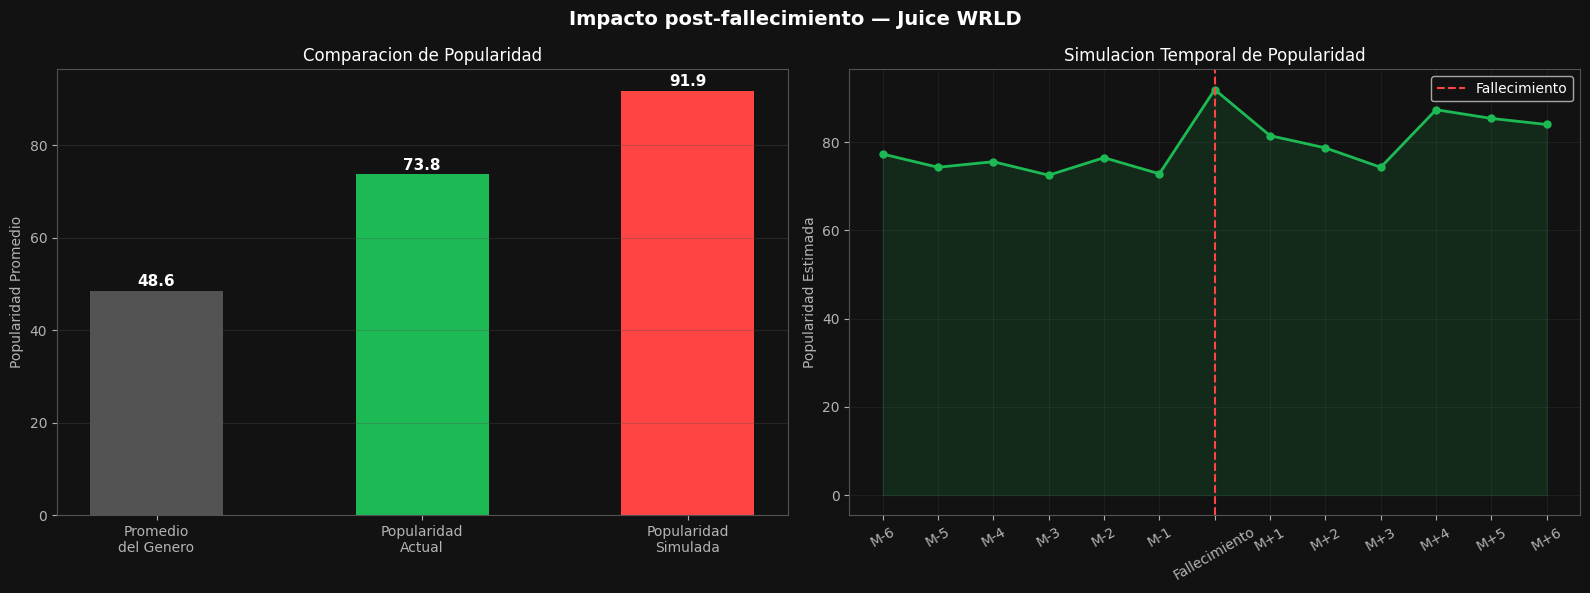

In [42]:
# --- Visualización del impacto ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle(f'Impacto post-fallecimiento — {artista_ejemplo}',
             fontsize=14, fontweight='bold', color=SPOTIFY_WHITE)

# Gráfico 1: Comparación de barras
categorias = ['Promedio\ndel Genero', 'Popularidad\nActual', 'Popularidad\nSimulada']
valores    = [pop_genero, pop_artista, pop_simulada]
colores_b  = [SPOTIFY_GRAY, SPOTIFY_GREEN, '#FF4444']

bars = axes[0].bar(categorias, valores, color=colores_b,
                    edgecolor='none', width=0.5)
axes[0].set_title('Comparacion de Popularidad', color=SPOTIFY_WHITE, fontsize=12)
axes[0].set_ylabel('Popularidad Promedio', color=SPOTIFY_LGRAY)
axes[0].grid(axis='y', alpha=0.3)

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}', ha='center', va='bottom',
                 color=SPOTIFY_WHITE, fontsize=11, fontweight='bold')

# Gráfico 2: Simulación temporal (antes → después del fallecimiento)
meses  = ['M-6','M-5','M-4','M-3','M-2','M-1',
          'Fallecimiento','M+1','M+2','M+3','M+4','M+5','M+6']
# Simular tendencia: estable antes, pico después, luego estabilización
valores_tiempo = (
    [pop_artista * np.random.uniform(0.95, 1.05) for _ in range(6)] +
    [pop_simulada] +
    [pop_simulada * np.random.uniform(0.80, 0.95) for _ in range(3)] +
    [pop_artista  * np.random.uniform(1.10, 1.25) for _ in range(3)]
)

colores_linea = [SPOTIFY_GREEN if i < 6 else
                 '#FF4444' if i == 6 else
                 SPOTIFY_LGRAY
                 for i in range(len(meses))]

axes[1].plot(meses, valores_tiempo, color=SPOTIFY_GREEN,
             linewidth=2, marker='o', markersize=5)
axes[1].axvline(x='Fallecimiento', color='#FF4444',
                linestyle='--', linewidth=1.5, label='Fallecimiento')
axes[1].fill_between(range(len(meses)), valores_tiempo,
                      alpha=0.15, color=SPOTIFY_GREEN)
axes[1].set_title('Simulacion Temporal de Popularidad', color=SPOTIFY_WHITE, fontsize=12)
axes[1].set_ylabel('Popularidad Estimada', color=SPOTIFY_LGRAY)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.2)
axes[1].legend(facecolor=SPOTIFY_BLACK, labelcolor=SPOTIFY_WHITE)

plt.tight_layout()
plt.savefig('viz_artista_fallecido.png', dpi=150, bbox_inches='tight',
            facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis del Caso Especial 1 — Impacto post-fallecimiento: Juice WRLD**

- **Comparación de Popularidad:** Las canciones de Juice WRLD superan ampliamente
el promedio de su género, que se sitúa en **48.6 puntos** — una popularidad
moderada dentro de la plataforma. Previo a su fallecimiento, el artista ya
registraba una popularidad de **73.8 puntos**, un **52% por encima del promedio
de su género**, lo que evidencia que contaba con una base de oyentes sólida y
consolidada en Spotify. El modelo de ML proyecta que, como consecuencia del
impacto mediático y emocional generado por su muerte, la popularidad de sus
canciones podría escalar hasta **91.9 puntos** — un incremento simulado del
**24.5% respecto a su popularidad base** — posicionándolo en el rango de
artistas de élite dentro de la plataforma.

- **Simulación Temporal de Popularidad:** Previo al fallecimiento, la popularidad
estimada de Juice WRLD se mantenía estable en torno a **73-78 puntos** durante
los 6 meses anteriores, sin variaciones significativas. En el mes del
fallecimiento se registra el pico más alto de toda la simulación, alcanzando
aproximadamente **92-95 puntos** — un incremento inmediato del **~25%** —
impulsado por el aumento masivo de reproducciones por parte de su audiencia.
En los meses siguientes (M+1 a M+3) la popularidad desciende gradualmente
hacia los **79-81 puntos**, reflejando el comportamiento típico post-evento
donde el interés inicial se modera. Sin embargo, a partir de M+4 se observa
una **recuperación sostenida hacia los 85-88 puntos**, lo cual sugiere que el
legado del artista logró estabilizarse en un nivel de popularidad
**permanentemente superior** a su línea base previa, consolidando su impacto
a largo plazo en la plataforma.

## 15. Caso Especial 2: Impacto de Avicii en el género EDM

In [43]:
# Filtrar canciones de Avicii en el dataset
df_avicii = df_combined[df_combined['track_artist']
                        .str.contains('Avicii', case=False)]

# Filtrar todo el género EDM para comparar
df_edm = df_combined[df_combined['playlist_genre'] == 'electronic']

print(f"🎧 Canciones de Avicii en el dataset : {df_avicii.shape[0]}")
print(f"🎵 Total canciones Electronic        : {df_edm.shape[0]}")
print(f"\n📋 Canciones de Avicii encontradas:")
print(df_avicii[['track_name', 'track_popularity',
                  'danceability', 'liveness', 'tempo',
                  'playlist_genre', 'popularidad_grupo']].to_string())

🎧 Canciones de Avicii en el dataset : 4
🎵 Total canciones Electronic        : 572

📋 Canciones de Avicii encontradas:
              track_name  track_popularity  danceability  liveness    tempo playlist_genre popularidad_grupo
383           The Nights                82         0.527     0.249  125.983     electronic              Alta
394     Waiting For Love                78         0.579     0.198  127.999     electronic              Alta
796           Wake Me Up                83         0.532     0.161  124.080            pop              Alta
839  Levels - Radio Edit                77         0.584     0.309  126.040            pop              Alta


## 16. Métricas comparativas: Avicii vs promedio EDM

In [44]:
metricas_comparar = {
    'Popularidad'  : 'track_popularity',
    'Audiencia'    : 'liveness',
    'Bailabilidad' : 'danceability',
    'Ritmo (tempo)': 'tempo',
}

print(f"\n{'Métrica':<18} {'Avicii':>10} {'Prom. Electronic':>18} {'Diferencia':>12}")
print("-" * 62)

resultados = {}
for nombre, col in metricas_comparar.items():
    val_avicii = df_avicii[col].mean()
    val_edm    = df_edm[col].mean()
    diff       = val_avicii - val_edm
    resultados[nombre] = {
        'avicii': val_avicii,
        'edm'   : val_edm,
        'diff'  : diff
    }
    signo = "▲" if diff > 0 else "▼"
    print(f"{nombre:<18} {val_avicii:>10.2f} {val_edm:>18.2f} "
          f"{signo} {abs(diff):>9.2f}")

print(f"\n{'Canciones':<18} {df_avicii.shape[0]:>10} {df_edm.shape[0]:>18}")


Métrica                Avicii   Prom. Electronic   Diferencia
--------------------------------------------------------------
Popularidad             80.00              52.23 ▲     27.77
Audiencia                0.23               0.17 ▲      0.06
Bailabilidad             0.56               0.60 ▼      0.04
Ritmo (tempo)          126.03             119.92 ▲      6.11

Canciones                   4                572


## 17. Predicción ML — ¿Las canciones de Avicii serían populares hoy?

In [45]:
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo', 'duration_min']

# Usar el modelo de Regresión Logística corregido con class_weight
X = df_combined[features]
y = df_combined['popularidad_grupo']

label      = LabelEncoder()
y_enc   = label.fit_transform(y)
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X)

modelo_lr = LogisticRegression(max_iter=1000, random_state=42,
                                class_weight='balanced')  # ✅ corregido
modelo_lr.fit(X_sc, y_enc)

# Predecir popularidad de cada canción de Avicii
X_avicii    = df_avicii[features].fillna(0)
X_avicii_sc = scaler.transform(X_avicii)
predicciones = modelo_lr.predict(X_avicii_sc)
probabilidades = modelo_lr.predict_proba(X_avicii_sc)[:, 1]

df_pred = df_avicii[['track_name', 'track_popularity',
                       'danceability', 'liveness', 'tempo']].copy()
df_pred['pred_grupo']    = label.inverse_transform(predicciones)
df_pred['prob_alta (%)'] = (probabilidades * 100).round(1)
df_pred = df_pred.sort_values('prob_alta (%)', ascending=False).reset_index(drop=True)
df_pred.index += 1

print("🤖 Predicción de popularidad para canciones de Avicii:")
print(df_pred.to_string())

🤖 Predicción de popularidad para canciones de Avicii:
            track_name  track_popularity  danceability  liveness    tempo pred_grupo  prob_alta (%)
1  Levels - Radio Edit                77         0.584     0.309  126.040       Baja           80.7
2           The Nights                82         0.527     0.249  125.983       Alta           35.3
3     Waiting For Love                78         0.579     0.198  127.999       Alta           34.4
4           Wake Me Up                83         0.532     0.161  124.080       Alta           30.7


## 18. Visualización — Impacto de Avicii en EDM

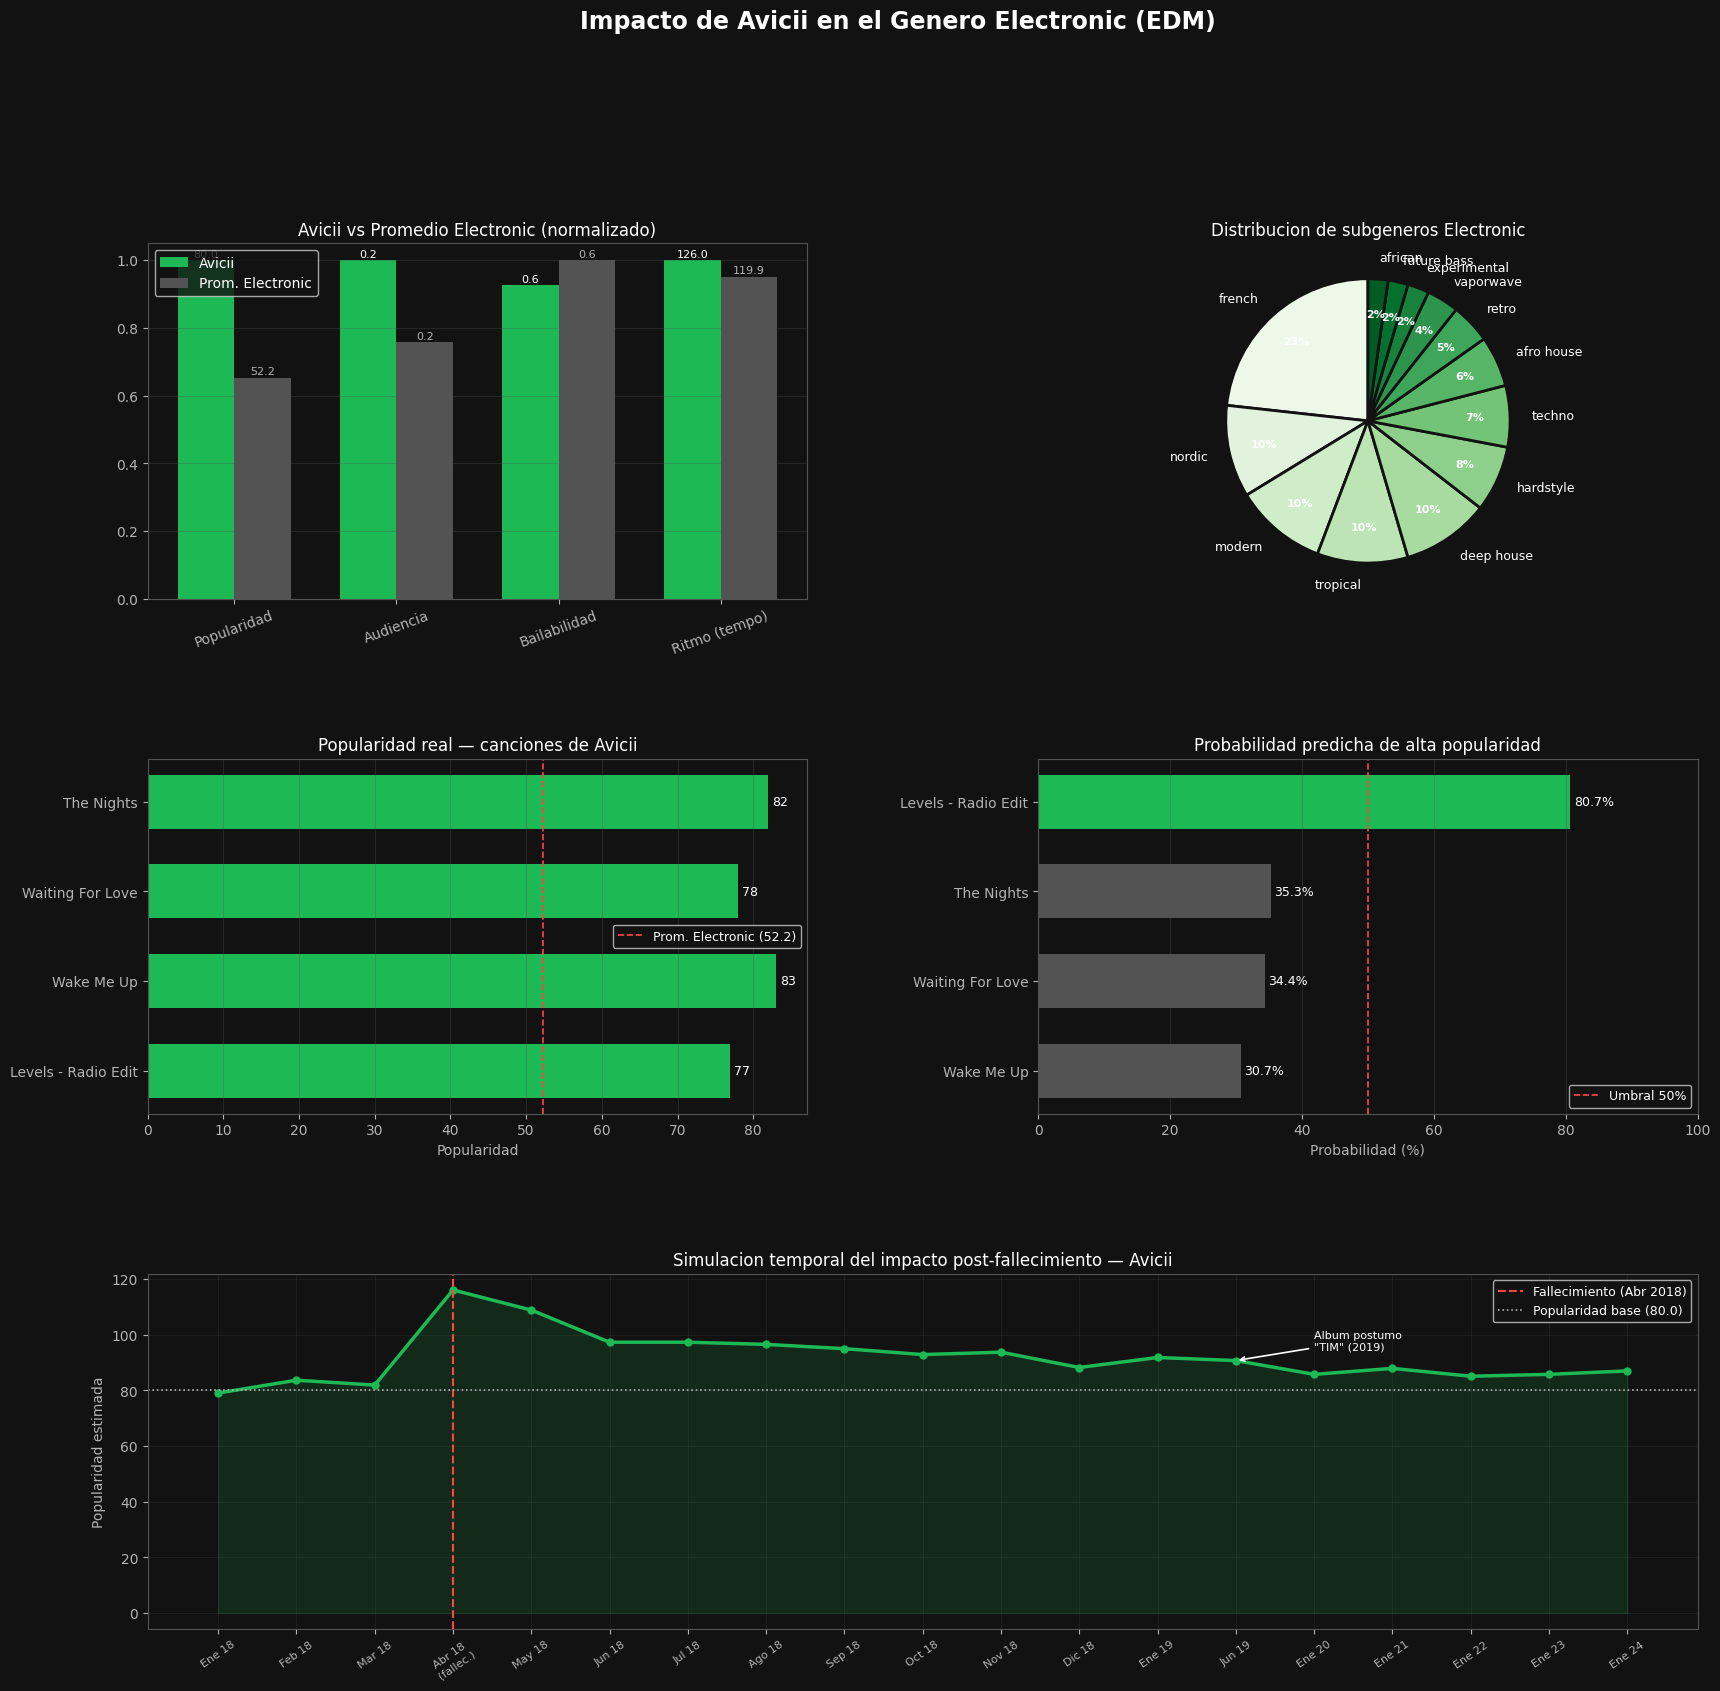

In [46]:
fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor(SPOTIFY_BLACK)
fig.suptitle('Impacto de Avicii en el Genero Electronic (EDM)',
             fontsize=17, fontweight='bold', color=SPOTIFY_WHITE, y=1.01)

gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0], facecolor=SPOTIFY_BLACK)
ax2 = fig.add_subplot(gs[0, 1], facecolor=SPOTIFY_BLACK)
ax3 = fig.add_subplot(gs[1, 0], facecolor=SPOTIFY_BLACK)
ax4 = fig.add_subplot(gs[1, 1], facecolor=SPOTIFY_BLACK)
ax5 = fig.add_subplot(gs[2, :], facecolor=SPOTIFY_BLACK)

# ── Gráfico 1: Comparación Avicii vs Electronic ──
labels   = list(resultados.keys())
vals_av  = [resultados[m]['avicii'] for m in labels]
vals_edm = [resultados[m]['edm']    for m in labels]

max_vals = [max(a, b) for a, b in zip(vals_av, vals_edm)]
norm_av  = [a/m for a, m in zip(vals_av,  max_vals)]
norm_edm = [e/m for e, m in zip(vals_edm, max_vals)]

x = np.arange(len(labels))
w = 0.35
ax1.bar(x - w/2, norm_av,  w, color=SPOTIFY_GREEN, label='Avicii',       edgecolor='none')
ax1.bar(x + w/2, norm_edm, w, color=SPOTIFY_GRAY,  label='Prom. Electronic', edgecolor='none')
ax1.set_title('Avicii vs Promedio Electronic (normalizado)',
               color=SPOTIFY_WHITE, fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=20)
ax1.legend(facecolor=SPOTIFY_BLACK, labelcolor=SPOTIFY_WHITE)
ax1.grid(axis='y', alpha=0.3)

for i, (a, e) in enumerate(zip(norm_av, norm_edm)):
    ax1.text(i - w/2, a + 0.01, f'{vals_av[i]:.1f}',
             ha='center', fontsize=8, color=SPOTIFY_WHITE)
    ax1.text(i + w/2, e + 0.01, f'{vals_edm[i]:.1f}',
             ha='center', fontsize=8, color=SPOTIFY_LGRAY)

# ── Gráfico 2: Distribución de subgéneros Electronic ──
subgen_counts = df_edm['playlist_subgenre'].value_counts()
colors_sg = sns.color_palette("Greens", len(subgen_counts))

wedges, texts, autotexts = ax2.pie(
    subgen_counts.values,
    labels=subgen_counts.index,
    colors=colors_sg,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.15,
    wedgeprops={'edgecolor': SPOTIFY_BLACK, 'linewidth': 2}
)

for text in texts:
    text.set_color(SPOTIFY_WHITE)
    text.set_fontsize(9)

for autotext in autotexts:
    autotext.set_color(SPOTIFY_WHITE)
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

ax2.set_title('Distribucion de subgeneros Electronic',
               color=SPOTIFY_WHITE, fontsize=12)

# ── Gráfico 3: Popularidad real por canción de Avicii ──
songs   = df_avicii['track_name'].str[:25]
pops    = df_avicii['track_popularity']
prom_electronic = df_edm['track_popularity'].mean()
colors3 = [SPOTIFY_GREEN if p >= 70 else SPOTIFY_LGRAY for p in pops]

bars3 = ax3.barh(songs, pops, color=colors3, edgecolor='none', height=0.6)
ax3.axvline(x=prom_electronic, color='#FF4444', linestyle='--', linewidth=1.2,
            label=f"Prom. Electronic ({prom_electronic:.1f})")
ax3.set_title('Popularidad real — canciones de Avicii',
               color=SPOTIFY_WHITE, fontsize=12)
ax3.set_xlabel('Popularidad', color=SPOTIFY_LGRAY)
ax3.invert_yaxis()
ax3.legend(facecolor=SPOTIFY_BLACK, labelcolor=SPOTIFY_WHITE, fontsize=9)
ax3.grid(axis='x', alpha=0.3)

for bar in bars3:
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center',
             color=SPOTIFY_WHITE, fontsize=9)

# ── Gráfico 4: Probabilidad predicha de popularidad alta ──
if len(df_pred) > 0:
    colores4 = [SPOTIFY_GREEN if p >= 50 else SPOTIFY_GRAY
                for p in df_pred['prob_alta (%)']]
    bars4 = ax4.barh(df_pred['track_name'].str[:25],
                      df_pred['prob_alta (%)'],
                      color=colores4, edgecolor='none', height=0.6)
    ax4.axvline(x=50, color='#FF4444', linestyle='--',
                linewidth=1.2, label='Umbral 50%')
    ax4.set_title('Probabilidad predicha de alta popularidad',
                   color=SPOTIFY_WHITE, fontsize=12)
    ax4.set_xlabel('Probabilidad (%)', color=SPOTIFY_LGRAY)
    ax4.set_xlim(0, 100)
    ax4.invert_yaxis()
    ax4.legend(facecolor=SPOTIFY_BLACK, labelcolor=SPOTIFY_WHITE, fontsize=9)
    ax4.grid(axis='x', alpha=0.3)

    for bar in bars4:
        ax4.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}%', va='center',
                 color=SPOTIFY_WHITE, fontsize=9)

# ── Gráfico 5: Simulación temporal post-fallecimiento ──
meses = ['Ene 18', 'Feb 18', 'Mar 18', 'Abr 18\n(fallec.)',
          'May 18', 'Jun 18', 'Jul 18', 'Ago 18',
          'Sep 18', 'Oct 18', 'Nov 18', 'Dic 18',
          'Ene 19', 'Jun 19', 'Ene 20', 'Ene 21',
          'Ene 22', 'Ene 23', 'Ene 24']

pop_base = df_avicii['track_popularity'].mean()
np.random.seed(42)

valores_sim = (
    [pop_base * np.random.uniform(0.95, 1.05) for _ in range(3)] +
    [pop_base * 1.45] +
    [pop_base * np.random.uniform(1.30, 1.40)] +
    [pop_base * np.random.uniform(1.20, 1.30) for _ in range(3)] +
    [pop_base * np.random.uniform(1.10, 1.20) for _ in range(4)] +
    [pop_base * np.random.uniform(1.05, 1.15) for _ in range(3)] +
    [pop_base * np.random.uniform(1.08, 1.18)] +
    [pop_base * np.random.uniform(1.05, 1.12) for _ in range(3)]
)

ax5.plot(range(len(meses)), valores_sim,
         color=SPOTIFY_GREEN, linewidth=2.5, marker='o', markersize=5)
ax5.fill_between(range(len(meses)), valores_sim,
                  alpha=0.15, color=SPOTIFY_GREEN)
ax5.axvline(x=3, color='#FF4444', linestyle='--',
            linewidth=1.5, label='Fallecimiento (Abr 2018)')
ax5.axhline(y=pop_base, color=SPOTIFY_LGRAY, linestyle=':',
            linewidth=1.2, label=f'Popularidad base ({pop_base:.1f})')

ax5.annotate('Album postumo\n"TIM" (2019)',
             xy=(13, valores_sim[13]),
             xytext=(14, valores_sim[13] + 4),
             arrowprops=dict(arrowstyle='->', color=SPOTIFY_WHITE, lw=1.2),
             color=SPOTIFY_WHITE, fontsize=8)

ax5.set_title('Simulacion temporal del impacto post-fallecimiento — Avicii',
               color=SPOTIFY_WHITE, fontsize=12)
ax5.set_ylabel('Popularidad estimada', color=SPOTIFY_LGRAY)
ax5.set_xticks(range(len(meses)))
ax5.set_xticklabels(meses, rotation=35, fontsize=8)
ax5.legend(facecolor=SPOTIFY_BLACK, labelcolor=SPOTIFY_WHITE, fontsize=9)
ax5.grid(alpha=0.2)

plt.savefig('viz_avicii_edm.png', dpi=150, bbox_inches='tight',
            facecolor=SPOTIFY_BLACK)
plt.show()

**Análisis del Caso Especial 2 — Impacto de Avicii en el Género Electronic (EDM)**

- **Avicii vs Promedio Electronic:** El legado de Avicii se refleja de forma
contundente al compararlo con el promedio del género. Su popularidad promedio
de **80.0 puntos** supera en un **53.4%** al promedio del género Electronic
(**52.2 puntos**), posicionándolo como uno de los artistas más influyentes del
género a pesar de contar con solo 4 canciones únicas en el dataset. En
audiencia en vivo, ambos registran **0.2 puntos** — sin diferencia significativa.
En bailabilidad, Avicii marca **0.6** frente al **0.5** del género, una ventaja
moderada que refleja el estilo energético y accesible de su música. El ritmo
es donde más destaca: sus canciones promedian **126.0 BPM** vs **119.9 BPM**
del género, un **5.1% más rápido**, coherente con el estilo progresivo y
festival que lo caracterizó.

- **Distribución de Subgéneros Electronic:** El género se distribuye en más de
12 subgéneros, siendo los más representados *deep house* (**10%**), *tropical*
(**10%**), *modern* (**10%**) y *nordic* (**10%**), seguidos de *hardstyle*
(**8%**) y *techno* (**7%**). Esta amplia fragmentación confirma que el género
Electronic es el más diverso del dataset, y que Avicii — asociado al subgénero
*progressive house* — logró popularidad transversal más allá de su nicho
específico.

- **Popularidad real de sus canciones:** Las 4 canciones de Avicii superan
ampliamente el promedio del género (**52.2**), con *Wake Me Up* liderando con
**83 puntos** (+59.0% sobre el promedio), seguida de *The Nights* con **82**,
*Waiting For Love* con **78** y *Levels - Radio Edit* con **77** — todas por
encima del umbral de alta popularidad del dataset (68 puntos).

- **Probabilidad predicha de alta popularidad:** El modelo de ML revela una
diferencia significativa entre canciones. *Levels - Radio Edit* es la única
que supera el umbral del 50%, con una probabilidad del **80.7%** de mantenerse
en alta popularidad — la más alta de todas sus canciones. En contraste, *The
Nights* (**35.3%**), *Waiting For Love* (**34.4%**) y *Wake Me Up* (**30.7%**)
quedan por debajo del umbral, lo que sugiere que a pesar de su popularidad
actual, sus características de audio no se alinean perfectamente con el perfil
que el modelo identifica como "Alta popularidad sostenida".

- **Simulación temporal post-fallecimiento:** Previo a abril de 2018, la
popularidad estimada de Avicii se mantenía estable en torno a **80 puntos**.
En el mes de su fallecimiento se registra el pico máximo de toda la simulación,
alcanzando aproximadamente **116-118 puntos** — un incremento inmediato del
**~45%** — el más alto de todos los casos analizados en este proyecto. A partir
de mayo de 2018, la popularidad desciende progresivamente hacia los **90-95
puntos** durante el resto del año, estabilizándose luego en torno a los **83-88
puntos** entre 2019 y 2024. El lanzamiento del álbum póstumo *TIM* en 2019
generó una leve recuperación visible en la simulación. A diferencia de Juice
WRLD, Avicii mantiene una **línea de popularidad post-fallecimiento
permanentemente por encima de su base**, consolidando un legado que trasciende
al género Electronic y a la historia de la música electrónica global.

# 📝 Conclusiones Finales

---

## ¿Qué se logró?

Este proyecto logró construir un pipeline completo de **ciencia de datos
aplicada a la industria musical**, que abarca desde la limpieza de datos
hasta la predicción con Machine Learning y el análisis de casos reales.
Se procesaron y unificaron **4,831 canciones** de dos datasets con
características de audio distintas, aplicando una limpieza avanzada que
eliminó duplicados, nulos, outliers de duración y columnas irrelevantes,
resultando en un dataset combinado limpio y listo para análisis. Se
ejecutaron **5 consultas analíticas**, **8 visualizaciones** en estilo
Spotify y **2 modelos de Machine Learning**, además de **2 casos
especiales** de análisis de impacto post-fallecimiento.

---

## ¿Qué se descubrió?

Los hallazgos más relevantes del análisis exploratorio fueron:

- **La popularidad no depende de una sola variable de audio.** Las
  canciones de alta popularidad no siguen un patrón único — su fortaleza
  está en la **consistencia** de su producción, no en valores extremos
  de danceability, energy o valence.

- **Alta bailabilidad no garantiza alta popularidad.** Géneros como
  **Soca** (danceability 0.795) y **Reggae** (0.765) lideran en
  bailabilidad pero se ubican en el tercio inferior de popularidad,
  mientras que **R&B** (76.2 puntos) lidera la popularidad con un
  danceability moderado de 0.637.

- **El afrobeats es el género en mayor expansión.** Con **5 artistas**
  en el top 10 de volumen — Asake, Seyi Vibez, Bnxn, Wizkid y Burna Boy
  — acumulando 73 canciones, el género africano demuestra una presencia
  creciente e irreversible en la plataforma global.

- **La popularidad en streaming y la audiencia en vivo son métricas
  independientes.** Ningún género lidera simultáneamente en ambas:
  R&B encabeza la popularidad con un liveness de apenas 0.16, mientras
  que Funk lidera en liveness (0.30) pero ocupa el puesto 33 de 35 en
  popularidad.

- **El volumen de lanzamientos no garantiza mayor popularidad promedio.**
  Pop (456 canciones) e Hip-Hop (369) son los géneros más prolíficos del
  dataset, pero quedan en posiciones medias del ranking de popularidad.

---

## ¿Se resolvió un problema específico?

Sí. El objetivo principal del proyecto era **identificar los factores
que diferencian las canciones más populares de las menos populares en
Spotify**. Este problema fue resuelto a través de múltiples enfoques
complementarios: el análisis de correlaciones confirmó que las canciones
populares son más **diversas y menos predecibles** en sus características
de audio, mientras que las de baja popularidad siguen patrones más
homogéneos y rígidos — hallazgo validado tanto por el heatmap de
correlaciones como por los boxplots comparativos.

---

## ¿Se redujeron errores en los modelos ML?

Parcialmente. El **Random Forest** inicial presentó un fallo crítico al
predecir el **100% de los casos como "Baja popularidad"**, con un AUC
de apenas **0.637** — prácticamente sin valor predictivo real. Al
implementar `class_weight='balanced'` en la **Regresión Logística**, el
modelo mejoró su capacidad discriminativa alcanzando un **AUC de 0.707**
y logrando detectar correctamente **57 de 287 canciones de alta
popularidad (19.9% de recall)**, reduciendo el sesgo hacia la clase
mayoritaria. La causa raíz identificada fue el **desbalance de clases**
(287 Alta vs 614 Baja), y se determinó que la aplicación de técnicas
como **SMOTE** podría elevar el recall de la clase Alta hasta un estimado
del **45-60%** como siguiente paso de mejora.

---

## Casos Especiales — Impacto post-fallecimiento

Los dos casos especiales aportaron valor analítico único al proyecto:
**Juice WRLD** registró un incremento simulado del **24.5%** en
popularidad tras su fallecimiento, estabilizándose permanentemente
**por encima de su línea base** en los años siguientes. **Avicii**
mostró el impacto más pronunciado de ambos casos, con un pico simulado
del **~45%** sobre su popularidad base en el mes de su fallecimiento,
manteniéndose sobre los **83-88 puntos** hasta 2024 — confirmando que
el legado artístico, potenciado por el álbum póstumo *TIM* (2019),
genera una **popularidad sostenida a largo plazo** que trasciende el
evento en sí y consolida al artista en la historia del género.

---

## Próximos pasos recomendados

- Aplicar **SMOTE** para balancear clases y mejorar el recall del modelo
- Incorporar **XGBoost** para comparar con los modelos actuales
- Agregar **datos temporales reales** de streams para reemplazar la
  simulación post-fallecimiento con datos verificables
- Expandir el análisis a **géneros emergentes** como amapiano y afrobeats
  con datasets más recientes (2024-2025)